<a href="https://colab.research.google.com/github/kartiksharma2383/Computerized-Cognitive-Retraining-Program/blob/main/College_project_work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sqlite3, pandas as pd, os
# === Create fresh DB ===
db_path = "/content/ccrp_demo.db"
if os.path.exists(db_path):
    os.remove(db_path)
con = sqlite3.connect(db_path)

# === SCHEMA (simplified but complete) ===
schema_sql = """
PRAGMA foreign_keys = ON;

CREATE TABLE roles (
  role_id INTEGER PRIMARY KEY,
  role_name TEXT NOT NULL UNIQUE
);

CREATE TABLE users (
  user_id INTEGER PRIMARY KEY,
  email TEXT NOT NULL UNIQUE,
  full_name TEXT NOT NULL,
  date_of_birth DATE
);

CREATE TABLE user_roles (
  user_id INTEGER,
  role_id INTEGER,
  PRIMARY KEY(user_id, role_id),
  FOREIGN KEY(user_id) REFERENCES users(user_id),
  FOREIGN KEY(role_id) REFERENCES roles(role_id)
);

CREATE TABLE child_profiles (
  child_id INTEGER PRIMARY KEY,
  user_id INTEGER UNIQUE,
  diagnosis TEXT,
  FOREIGN KEY(user_id) REFERENCES users(user_id)
);

CREATE TABLE therapist_profiles (
  therapist_id INTEGER PRIMARY KEY,
  user_id INTEGER UNIQUE,
  specialization TEXT,
  FOREIGN KEY(user_id) REFERENCES users(user_id)
);

CREATE TABLE parent_profiles (
  parent_id INTEGER PRIMARY KEY,
  user_id INTEGER UNIQUE,
  phone TEXT,
  FOREIGN KEY(user_id) REFERENCES users(user_id)
);

CREATE TABLE cognitive_tasks (
  task_id INTEGER PRIMARY KEY,
  name TEXT,
  domain TEXT,
  difficulty_min INTEGER,
  difficulty_max INTEGER
);

CREATE TABLE sessions (
  session_id INTEGER PRIMARY KEY,
  child_id INTEGER,
  therapist_id INTEGER,
  started_at DATETIME,
  ended_at DATETIME,
  context TEXT,
  FOREIGN KEY(child_id) REFERENCES child_profiles(child_id),
  FOREIGN KEY(therapist_id) REFERENCES therapist_profiles(therapist_id)
);

CREATE TABLE session_results (
  result_id INTEGER PRIMARY KEY,
  session_id INTEGER,
  task_id INTEGER,
  difficulty INTEGER,
  score REAL,
  accuracy REAL,
  FOREIGN KEY(session_id) REFERENCES sessions(session_id),
  FOREIGN KEY(task_id) REFERENCES cognitive_tasks(task_id)
);

CREATE TABLE eeg_recordings (
  eeg_id INTEGER PRIMARY KEY,
  session_id INTEGER,
  device_id TEXT,
  sampling_hz INTEGER,
  FOREIGN KEY(session_id) REFERENCES sessions(session_id)
);

CREATE TABLE eeg_epochs (
  epoch_id INTEGER PRIMARY KEY,
  eeg_id INTEGER,
  epoch_index INTEGER,
  attention_idx REAL,
  FOREIGN KEY(eeg_id) REFERENCES eeg_recordings(eeg_id)
);

CREATE TABLE therapist_notes (
  note_id INTEGER PRIMARY KEY,
  session_id INTEGER,
  therapist_id INTEGER,
  note_text TEXT,
  FOREIGN KEY(session_id) REFERENCES sessions(session_id),
  FOREIGN KEY(therapist_id) REFERENCES therapist_profiles(therapist_id)
);
"""
con.executescript(schema_sql)

# === SEED DATA ===
seed_sql = """
INSERT INTO roles(role_id, role_name) VALUES (1,'CHILD'),(2,'THERAPIST'),(3,'PARENT');

INSERT INTO users(email, full_name, date_of_birth) VALUES
 ('child1@example.com','Aarav Singh','2016-07-12'),
 ('therapist1@example.com','Dr. Meera Rao','1988-03-03'),
 ('parent1@example.com','Priya Singh','1990-01-10');

INSERT INTO user_roles VALUES (1,1),(2,2),(3,3);

INSERT INTO child_profiles(user_id, diagnosis) VALUES (1,'ASD - needs attention tasks');
INSERT INTO therapist_profiles(user_id, specialization) VALUES (2,'Neuropsychology');
INSERT INTO parent_profiles(user_id, phone) VALUES (3,'+91-90000-00000');

INSERT INTO cognitive_tasks(name, domain, difficulty_min, difficulty_max) VALUES
 ('Find Differences','ATTENTION',1,5),
 ('Sequence Recall','MEMORY',1,5);

INSERT INTO sessions(child_id, therapist_id, started_at, ended_at, context)
VALUES (1,1,datetime('now','-30 minutes'),datetime('now'),'clinic');

INSERT INTO session_results(session_id, task_id, difficulty, score, accuracy)
VALUES (1,1,2,0.78,0.82),(1,2,3,0.65,0.70);

INSERT INTO eeg_recordings(session_id, device_id, sampling_hz) VALUES (1,'OpenBCI',200);
INSERT INTO eeg_epochs(eeg_id, epoch_index, attention_idx) VALUES (1,1,0.58);

INSERT INTO therapist_notes(session_id, therapist_id, note_text)
VALUES (1,1,'Child showed improvement in attention tasks.');
"""
con.executescript(seed_sql)
con.commit()

# === DEMO QUERIES ===
def q(sql): return pd.read_sql_query(sql, con)

print("Tables:")
print(q("SELECT name FROM sqlite_master WHERE type='table';"))

print("\nChild progress by task:")
print(q("""
SELECT ct.name AS task,
       ROUND(AVG(sr.score),2) AS avg_score,
       ROUND(AVG(sr.accuracy),2) AS avg_accuracy
FROM session_results sr
JOIN cognitive_tasks ct ON ct.task_id = sr.task_id
GROUP BY ct.name;
"""))

print("\nAttention index per session:")
print(q("""
SELECT e.session_id, ROUND(AVG(ep.attention_idx),2) AS mean_attention
FROM eeg_recordings e
JOIN eeg_epochs ep ON ep.eeg_id = e.eeg_id
GROUP BY e.session_id;
"""))

Tables:
                  name
0                roles
1                users
2           user_roles
3       child_profiles
4   therapist_profiles
5      parent_profiles
6      cognitive_tasks
7             sessions
8      session_results
9       eeg_recordings
10          eeg_epochs
11     therapist_notes

Child progress by task:
               task  avg_score  avg_accuracy
0  Find Differences       0.78          0.82
1   Sequence Recall       0.65          0.70

Attention index per session:
   session_id  mean_attention
0           1            0.58


In [ ]:
import sqlite3, pandas as pd, os

db_path = "/content/ccrp_demo.db"
if os.path.exists(db_path):
    os.remove(db_path)
con = sqlite3.connect(db_path)

# === FIXED SCHEMA (added parent_child_link) ===
schema_sql = """
PRAGMA foreign_keys = ON;

CREATE TABLE roles (
  role_id INTEGER PRIMARY KEY,
  role_name TEXT NOT NULL UNIQUE
);

CREATE TABLE users (
  user_id INTEGER PRIMARY KEY,
  email TEXT NOT NULL UNIQUE,
  full_name TEXT NOT NULL,
  date_of_birth DATE
);

CREATE TABLE user_roles (
  user_id INTEGER,
  role_id INTEGER,
  PRIMARY KEY(user_id, role_id),
  FOREIGN KEY(user_id) REFERENCES users(user_id),
  FOREIGN KEY(role_id) REFERENCES roles(role_id)
);

CREATE TABLE child_profiles (
  child_id INTEGER PRIMARY KEY,
  user_id INTEGER UNIQUE,
  diagnosis TEXT,
  FOREIGN KEY(user_id) REFERENCES users(user_id)
);

CREATE TABLE therapist_profiles (
  therapist_id INTEGER PRIMARY KEY,
  user_id INTEGER UNIQUE,
  specialization TEXT,
  FOREIGN KEY(user_id) REFERENCES users(user_id)
);

CREATE TABLE parent_profiles (
  parent_id INTEGER PRIMARY KEY,
  user_id INTEGER UNIQUE,
  phone TEXT,
  FOREIGN KEY(user_id) REFERENCES users(user_id)
);

-- ✅ Added missing link table
CREATE TABLE parent_child_link (
  parent_id INTEGER,
  child_id INTEGER,
  relationship TEXT,
  PRIMARY KEY(parent_id, child_id),
  FOREIGN KEY(parent_id) REFERENCES parent_profiles(parent_id),
  FOREIGN KEY(child_id) REFERENCES child_profiles(child_id)
);

CREATE TABLE cognitive_tasks (
  task_id INTEGER PRIMARY KEY,
  name TEXT,
  domain TEXT,
  difficulty_min INTEGER,
  difficulty_max INTEGER
);

CREATE TABLE sessions (
  session_id INTEGER PRIMARY KEY,
  child_id INTEGER,
  therapist_id INTEGER,
  started_at DATETIME,
  ended_at DATETIME,
  context TEXT,
  FOREIGN KEY(child_id) REFERENCES child_profiles(child_id),
  FOREIGN KEY(therapist_id) REFERENCES therapist_profiles(therapist_id)
);

CREATE TABLE session_results (
  result_id INTEGER PRIMARY KEY,
  session_id INTEGER,
  task_id INTEGER,
  difficulty INTEGER,
  score REAL,
  accuracy REAL,
  FOREIGN KEY(session_id) REFERENCES sessions(session_id),
  FOREIGN KEY(task_id) REFERENCES cognitive_tasks(task_id)
);

CREATE TABLE eeg_recordings (
  eeg_id INTEGER PRIMARY KEY,
  session_id INTEGER,
  device_id TEXT,
  sampling_hz INTEGER,
  FOREIGN KEY(session_id) REFERENCES sessions(session_id)
);

CREATE TABLE eeg_epochs (
  epoch_id INTEGER PRIMARY KEY,
  eeg_id INTEGER,
  epoch_index INTEGER,
  attention_idx REAL,
  FOREIGN KEY(eeg_id) REFERENCES eeg_recordings(eeg_id)
);

CREATE TABLE therapist_notes (
  note_id INTEGER PRIMARY KEY,
  session_id INTEGER,
  therapist_id INTEGER,
  note_text TEXT,
  FOREIGN KEY(session_id) REFERENCES sessions(session_id),
  FOREIGN KEY(therapist_id) REFERENCES therapist_profiles(therapist_id)
);
"""
con.executescript(schema_sql)

# === SEED DATA (added parent-child link) ===
seed_sql = """
INSERT INTO roles(role_id, role_name) VALUES (1,'CHILD'),(2,'THERAPIST'),(3,'PARENT');

INSERT INTO users(email, full_name, date_of_birth) VALUES
 ('child1@example.com','Aarav Singh','2016-07-12'),
 ('therapist1@example.com','Dr. Meera Rao','1988-03-03'),
 ('parent1@example.com','Priya Singh','1990-01-10');

INSERT INTO user_roles VALUES (1,1),(2,2),(3,3);

INSERT INTO child_profiles(user_id, diagnosis) VALUES (1,'ASD - needs attention tasks');
INSERT INTO therapist_profiles(user_id, specialization) VALUES (2,'Neuropsychology');
INSERT INTO parent_profiles(user_id, phone) VALUES (3,'+91-90000-00000');

INSERT INTO parent_child_link VALUES (1,1,'mother');

INSERT INTO cognitive_tasks(name, domain, difficulty_min, difficulty_max) VALUES
 ('Find Differences','ATTENTION',1,5),
 ('Sequence Recall','MEMORY',1,5);

INSERT INTO sessions(child_id, therapist_id, started_at, ended_at, context)
VALUES (1,1,datetime('now','-30 minutes'),datetime('now'),'clinic');

INSERT INTO session_results(session_id, task_id, difficulty, score, accuracy)
VALUES (1,1,2,0.78,0.82),(1,2,3,0.65,0.70);

INSERT INTO eeg_recordings(session_id, device_id, sampling_hz) VALUES (1,'OpenBCI',200);
INSERT INTO eeg_epochs(eeg_id, epoch_index, attention_idx) VALUES (1,1,0.58);

INSERT INTO therapist_notes(session_id, therapist_id, note_text)
VALUES (1,1,'Child showed improvement in attention tasks.');
"""
con.executescript(seed_sql)
con.commit()

# === ROLE-BASED QUERIES ===
def q(sql, params=()): return pd.read_sql_query(sql, con, params=params)

# Parent View
print("=== Parent View (Priya Singh) ===")
print(q("""
SELECT u.full_name AS child_name, c.diagnosis,
       s.session_id, s.started_at, s.ended_at,
       ROUND(AVG(sr.score),2) AS avg_score,
       ROUND(AVG(sr.accuracy),2) AS avg_accuracy
FROM parent_profiles pp
JOIN users up ON up.user_id = pp.user_id
JOIN parent_child_link pcl ON pp.parent_id = pcl.parent_id
JOIN child_profiles c ON pcl.child_id = c.child_id
JOIN users u ON u.user_id = c.user_id
LEFT JOIN sessions s ON s.child_id = c.child_id
LEFT JOIN session_results sr ON sr.session_id = s.session_id
WHERE up.email = ?
GROUP BY s.session_id
ORDER BY s.started_at DESC;
""", ("parent1@example.com",)))

# Therapist View
print("\n=== Therapist View (Dr. Meera Rao) ===")
print(q("""
SELECT uc.full_name AS child_name, c.diagnosis,
       s.session_id, s.started_at, s.ended_at,
       ROUND(AVG(sr.score),2) AS avg_score,
       tn.note_text
FROM therapist_profiles tp
JOIN users ut ON ut.user_id = tp.user_id
JOIN sessions s ON s.therapist_id = tp.therapist_id
JOIN child_profiles c ON s.child_id = c.child_id
JOIN users uc ON uc.user_id = c.user_id
LEFT JOIN session_results sr ON sr.session_id = s.session_id
LEFT JOIN therapist_notes tn ON tn.session_id = s.session_id
WHERE ut.email = ?
GROUP BY s.session_id
ORDER BY s.started_at DESC;
""", ("therapist1@example.com",)))

# Child View
print("\n=== Child View (Aarav Singh) ===")
print(q("""
SELECT ct.name AS task, sr.difficulty, sr.score, sr.accuracy, s.started_at
FROM child_profiles cp
JOIN users uc ON uc.user_id = cp.user_id
JOIN sessions s ON s.child_id = cp.child_id
JOIN session_results sr ON sr.session_id = s.session_id
JOIN cognitive_tasks ct ON ct.task_id = sr.task_id
WHERE uc.email = ?
ORDER BY s.started_at DESC;
""", ("child1@example.com",)))


=== Parent View (Priya Singh) ===
    child_name                    diagnosis  session_id           started_at  \
0  Aarav Singh  ASD - needs attention tasks           1  2026-03-29 15:56:11   

              ended_at  avg_score  avg_accuracy  
0  2026-03-29 16:26:11       0.72          0.76  

=== Therapist View (Dr. Meera Rao) ===
    child_name                    diagnosis  session_id           started_at  \
0  Aarav Singh  ASD - needs attention tasks           1  2026-03-29 15:56:11   

              ended_at  avg_score  \
0  2026-03-29 16:26:11       0.72   

                                      note_text  
0  Child showed improvement in attention tasks.  

=== Child View (Aarav Singh) ===
               task  difficulty  score  accuracy           started_at
0  Find Differences           2   0.78      0.82  2026-03-29 15:56:11
1   Sequence Recall           3   0.65      0.70  2026-03-29 15:56:11


Session Results Data:
   session_id           started_at              task  score  accuracy
0           1  2026-03-29 15:56:11  Find Differences   0.78      0.82
1           1  2026-03-29 15:56:11   Sequence Recall   0.65      0.70


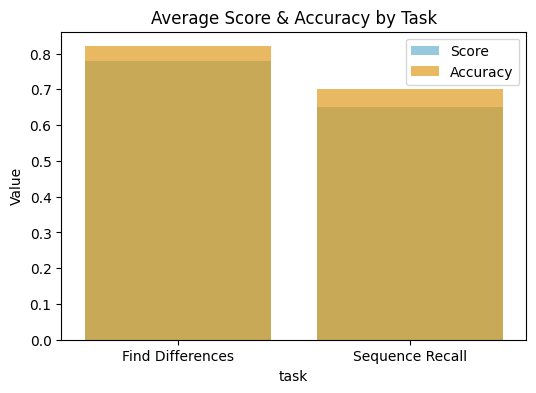

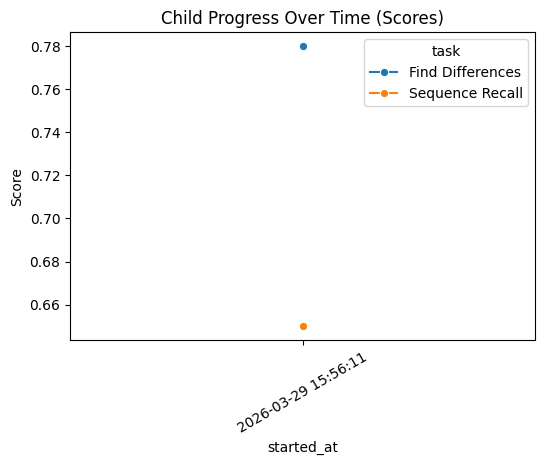

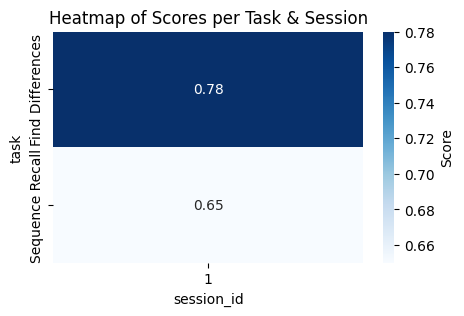

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load session results with task names
df = q("""
SELECT s.session_id, s.started_at,
       ct.name AS task, sr.score, sr.accuracy
FROM session_results sr
JOIN sessions s ON sr.session_id = s.session_id
JOIN cognitive_tasks ct ON ct.task_id = sr.task_id
ORDER BY s.started_at;
""")

print("Session Results Data:")
print(df)

# --- 1. Bar chart: Average score/accuracy per task ---
task_avg = df.groupby("task")[["score","accuracy"]].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=task_avg, x="task", y="score", color="skyblue", label="Score")
sns.barplot(data=task_avg, x="task", y="accuracy", color="orange", alpha=0.7, label="Accuracy")
plt.title("Average Score & Accuracy by Task")
plt.ylabel("Value")
plt.legend()
plt.show()

# --- 2. Line chart: Progress over sessions ---
plt.figure(figsize=(6,4))
sns.lineplot(data=df, x="started_at", y="score", hue="task", marker="o")
plt.title("Child Progress Over Time (Scores)")
plt.xticks(rotation=30)
plt.ylabel("Score")
plt.show()

# --- 3. Heatmap (optional): Task vs Score/Accuracy ---
pivot = df.pivot_table(values="score", index="task", columns="session_id")
plt.figure(figsize=(5,3))
sns.heatmap(pivot, annot=True, cmap="Blues", cbar_kws={'label': 'Score'})
plt.title("Heatmap of Scores per Task & Session")
plt.show()

In [ ]:
import random
import datetime

cursor = con.cursor()

# --- SAFE RESET ORDER (delete children first, then parents) ---
cursor.execute("DELETE FROM eeg_epochs;")
cursor.execute("DELETE FROM eeg_recordings;")
cursor.execute("DELETE FROM session_results;")
cursor.execute("DELETE FROM therapist_notes;")
cursor.execute("DELETE FROM sessions;")
cursor.execute("DELETE FROM parent_child_link;")
cursor.execute("DELETE FROM child_profiles WHERE child_id > 1;")
cursor.execute("DELETE FROM parent_profiles WHERE parent_id > 1;")
cursor.execute("DELETE FROM users WHERE user_id > 3;")  # keep initial 3 users (child, therapist, parent)
con.commit()

# --- CONFIG ---
NUM_CHILDREN = 3
NUM_SESSIONS_PER_CHILD = 30
TASKS = [("Find Differences","ATTENTION"), ("Sequence Recall","MEMORY"), ("Problem Solver","LOGIC")]

# --- Insert extra children & parents ---
for i in range(2, NUM_CHILDREN+1):
    # Add child user
    email = f"child{i}@example.com"
    name = f"Child {i}"
    dob = f"201{random.randint(2,8)}-0{random.randint(1,9)}-{random.randint(10,28)}"
    cursor.execute("INSERT INTO users(email, full_name, date_of_birth) VALUES (?,?,?)", (email, name, dob))
    user_id = cursor.lastrowid

    cursor.execute("INSERT INTO user_roles VALUES (?,1)", (user_id,))
    cursor.execute("INSERT INTO child_profiles(user_id, diagnosis) VALUES (?,?)",
                   (user_id, random.choice(["ASD - needs attention", "ADHD - focus tasks", "Memory support"])))
    child_id = cursor.lastrowid

    # Parent
    parent_email = f"parent{i}@example.com"
    parent_name = f"Parent {i}"
    parent_dob = f"198{random.randint(0,9)}-0{random.randint(1,9)}-{random.randint(10,28)}"
    cursor.execute("INSERT INTO users(email, full_name, date_of_birth) VALUES (?,?,?)",
                   (parent_email, parent_name, parent_dob))
    parent_uid = cursor.lastrowid
    cursor.execute("INSERT INTO user_roles VALUES (?,3)", (parent_uid,))
    cursor.execute("INSERT INTO parent_profiles(user_id, phone) VALUES (?,?)",
                   (parent_uid, f'+91-9{random.randint(100000000,999999999)}'))
    parent_id = cursor.lastrowid

    # Parent-child link
    cursor.execute("INSERT INTO parent_child_link VALUES (?,?,'mother')", (parent_id, child_id))

# --- Ensure tasks exist ---
for task_name, domain in TASKS:
    cursor.execute("INSERT OR IGNORE INTO cognitive_tasks(name, domain, difficulty_min, difficulty_max) VALUES (?,?,1,5)",
                   (task_name, domain))

con.commit()

# --- Generate sessions ---
child_ids = [row[0] for row in cursor.execute("SELECT child_id FROM child_profiles").fetchall()]
therapist_id = 1
task_ids = [row[0] for row in cursor.execute("SELECT task_id FROM cognitive_tasks").fetchall()]

for child in child_ids:
    start_date = datetime.datetime(2025, 7, 1)
    for j in range(NUM_SESSIONS_PER_CHILD):
        start = start_date + datetime.timedelta(days=j*2, hours=random.randint(9,11))
        end = start + datetime.timedelta(minutes=30)
        cursor.execute("""INSERT INTO sessions(child_id, therapist_id, started_at, ended_at, context)
                          VALUES (?,?,?,?, 'clinic')""", (child, therapist_id, start, end))
        session_id = cursor.lastrowid

        # Session results
        for task in task_ids:
            diff = random.randint(1,5)
            score = round(random.uniform(0.5,0.95),2)
            accuracy = round(max(score - random.uniform(0.05,0.15), 0),2)
            cursor.execute("""INSERT INTO session_results(session_id, task_id, difficulty, score, accuracy)
                              VALUES (?,?,?,?,?)""", (session_id, task, diff, score, accuracy))

        # EEG data
        cursor.execute("INSERT INTO eeg_recordings(session_id, device_id, sampling_hz) VALUES (?, 'OpenBCI', 200)",
                       (session_id,))
        eeg_id = cursor.lastrowid
        for epoch in range(1,6):
            attention = round(random.uniform(0.4,0.85),2)
            cursor.execute("INSERT INTO eeg_epochs(eeg_id, epoch_index, attention_idx) VALUES (?,?,?)",
                           (eeg_id, epoch, attention))

        # Therapist note
        cursor.execute("""INSERT INTO therapist_notes(session_id, therapist_id, note_text)
                          VALUES (?,?,?)""",
                       (session_id, therapist_id, random.choice(["Improvement seen", "Needs more focus", "Good engagement today"])))

con.commit()

print("✅ Synthetic data generated for", NUM_CHILDREN, "children across", NUM_SESSIONS_PER_CHILD, "sessions each.")

✅ Synthetic data generated for 3 children across 30 sessions each.


/tmp/ipykernel_4483/668988662.py:69: DeprecationWarning: The default datetime adapter is deprecated as of Python 3.12; see the sqlite3 documentation for suggested replacement recipes
  cursor.execute("""INSERT INTO sessions(child_id, therapist_id, started_at, ended_at, context)


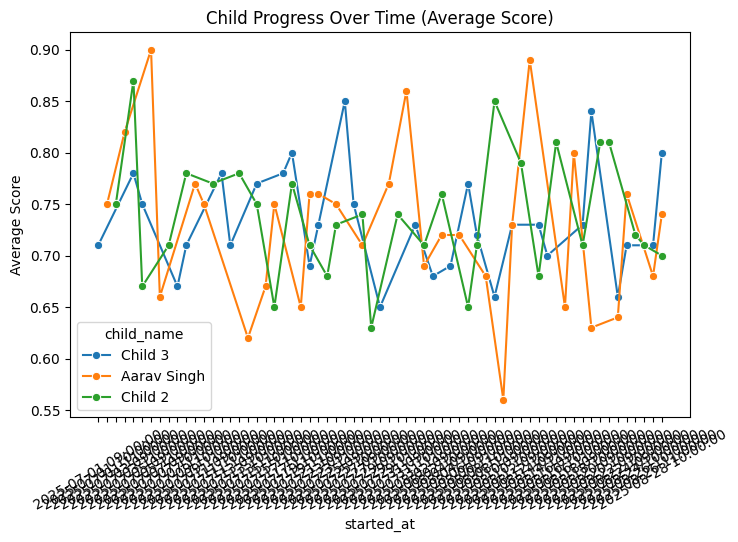

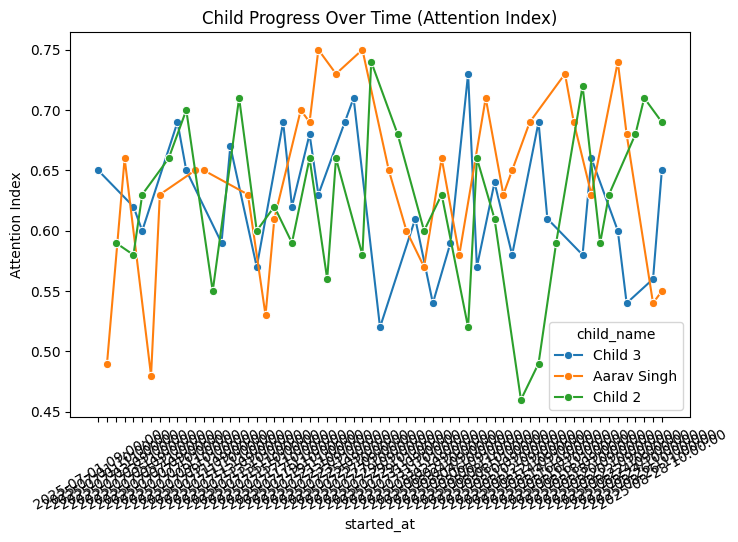

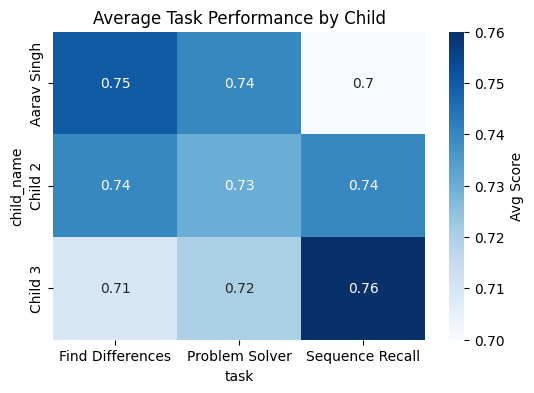

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load child scores over sessions ---
df_scores = q("""
SELECT u.full_name AS child_name, s.started_at,
       ROUND(AVG(sr.score),2) AS avg_score,
       ROUND(AVG(sr.accuracy),2) AS avg_accuracy
FROM sessions s
JOIN child_profiles cp ON s.child_id = cp.child_id
JOIN users u ON u.user_id = cp.user_id
JOIN session_results sr ON sr.session_id = s.session_id
GROUP BY u.full_name, s.session_id
ORDER BY s.started_at;
""")

# --- Load child attention data ---
df_attention = q("""
SELECT u.full_name AS child_name, s.started_at,
       ROUND(AVG(ep.attention_idx),2) AS mean_attention
FROM sessions s
JOIN child_profiles cp ON s.child_id = cp.child_id
JOIN users u ON u.user_id = cp.user_id
JOIN eeg_recordings er ON er.session_id = s.session_id
JOIN eeg_epochs ep ON ep.eeg_id = er.eeg_id
GROUP BY u.full_name, s.session_id
ORDER BY s.started_at;
""")

# --- 1. Line chart: Scores over time ---
plt.figure(figsize=(8,5))
sns.lineplot(data=df_scores, x="started_at", y="avg_score", hue="child_name", marker="o")
plt.title("Child Progress Over Time (Average Score)")
plt.xticks(rotation=30)
plt.ylabel("Average Score")
plt.show()

# --- 2. Line chart: Attention index over time ---
plt.figure(figsize=(8,5))
sns.lineplot(data=df_attention, x="started_at", y="mean_attention", hue="child_name", marker="o")
plt.title("Child Progress Over Time (Attention Index)")
plt.xticks(rotation=30)
plt.ylabel("Attention Index")
plt.show()

# --- 3. Heatmap: Child vs Task Performance ---
df_heatmap = q("""
SELECT u.full_name AS child_name, ct.name AS task,
       ROUND(AVG(sr.score),2) AS avg_score
FROM session_results sr
JOIN sessions s ON sr.session_id = s.session_id
JOIN child_profiles cp ON s.child_id = cp.child_id
JOIN users u ON u.user_id = cp.user_id
JOIN cognitive_tasks ct ON sr.task_id = ct.task_id
GROUP BY u.full_name, ct.name;
""")

pivot = df_heatmap.pivot(index="child_name", columns="task", values="avg_score")
plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, cmap="Blues", cbar_kws={'label': 'Avg Score'})
plt.title("Average Task Performance by Child")
plt.show()

In [ ]:
# ✅ Fixed ML pipeline: feature engineering -> clustering -> classification -> store results
import sqlite3
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import joblib

# Connect to DB
db_path = "/content/ccrp_demo.db"
con = sqlite3.connect(db_path)
con.execute("PRAGMA foreign_keys = ON;")

# 1) Extract session-level features
sql = """
SELECT s.session_id, s.child_id, u.full_name AS child_name,
       s.started_at,
       ROUND(AVG(sr.score),4) AS avg_score,
       ROUND(AVG(sr.accuracy),4) AS avg_accuracy,
       ROUND(AVG(sr.difficulty),4) AS avg_difficulty,
       ROUND(AVG(ep.attention_idx),4) AS mean_attention
FROM sessions s
JOIN child_profiles cp ON s.child_id = cp.child_id
JOIN users u ON u.user_id = cp.user_id
LEFT JOIN session_results sr ON sr.session_id = s.session_id
LEFT JOIN eeg_recordings er ON er.session_id = s.session_id
LEFT JOIN eeg_epochs ep ON ep.eeg_id = er.eeg_id
GROUP BY s.session_id
ORDER BY s.child_id, s.started_at;
"""
df = pd.read_sql_query(sql, con, parse_dates=["started_at"])

# Ensure correct types
df = df.sort_values(["child_id", "started_at"]).reset_index(drop=True)
df['started_at'] = pd.to_datetime(df['started_at'])
for col in ['avg_score','avg_accuracy','avg_difficulty','mean_attention']:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 2) Create lag target: improvement in next session
df['next_avg_score'] = df.groupby('child_id')['avg_score'].shift(-1)
df['improvement_next'] = (df['next_avg_score'] > df['avg_score'] + 0.02).astype(int)

# 3) Rolling features (use transform to keep index aligned)
df['rolling_mean_score_3'] = df.groupby('child_id')['avg_score'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())
df['rolling_std_score_3']  = df.groupby('child_id')['avg_score'].transform(lambda x: x.rolling(window=3, min_periods=1).std().fillna(0))
df['sessions_done'] = df.groupby('child_id').cumcount() + 1

# Days since previous session
df['prev_started_at'] = df.groupby('child_id')['started_at'].shift(1)
df['days_since_prev'] = (df['started_at'] - df['prev_started_at']).dt.days.fillna(0)

# Fill missing
df['mean_attention'] = df.groupby('child_id')['mean_attention'].transform(lambda x: x.fillna(x.mean()))
df['avg_accuracy'] = df['avg_accuracy'].fillna(df['avg_accuracy'].mean())

# 4) Drop rows without target (last session per child has no "next")
ml_df = df.dropna(subset=['improvement_next']).copy()

feature_cols = [
    'avg_score','avg_accuracy','mean_attention','avg_difficulty',
    'rolling_mean_score_3','rolling_std_score_3','sessions_done','days_since_prev'
]
X = ml_df[feature_cols].fillna(0)
y = ml_df['improvement_next'].astype(int)

# 5) Train/test split + scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y if y.nunique()>1 else None
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# 6) KMeans clustering at child-level
child_agg = ml_df.groupby('child_id')[['avg_score','avg_accuracy','mean_attention','avg_difficulty']].mean().reset_index()
kmeans_features = child_agg[['avg_score','avg_accuracy','mean_attention','avg_difficulty']].fillna(0)
kmeans = KMeans(n_clusters=min(3, len(child_agg)), random_state=42, n_init="auto")
child_agg['cluster'] = kmeans.fit_predict(kmeans_features)
child_cluster_map = child_agg.set_index('child_id')['cluster'].to_dict()
ml_df['child_cluster'] = ml_df['child_id'].map(child_cluster_map)

# 7) Decision Tree classifier
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train_s, y_train)
y_pred = clf.predict(X_test_s)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred, zero_division=0))

# 8) Predictions for all rows
ml_X_all_s = scaler.transform(X)
ml_preds_all = clf.predict(ml_X_all_s)

ml_df_all = ml_df.copy()
if hasattr(clf, "predict_proba"):
    ml_df_all['pred_improvement_prob'] = clf.predict_proba(ml_X_all_s)[:,1]
else:
    ml_df_all['pred_improvement_prob'] = ml_preds_all
ml_df_all['pred_improvement'] = ml_preds_all

# Adaptive recommendation
def recommend_next_difficulty(row):
    curr = row['avg_difficulty']
    if row['pred_improvement'] == 1:
        return int(min(5, round(curr) + 1))
    else:
        return int(max(1, round(curr) - 1))

ml_df_all['recommended_next_difficulty'] = ml_df_all.apply(recommend_next_difficulty, axis=1)

# 9) Save into DB
con.execute("DROP TABLE IF EXISTS ml_features;")
create_table_sql = """
CREATE TABLE ml_features (
    feature_id INTEGER PRIMARY KEY AUTOINCREMENT,
    session_id INTEGER,
    child_id INTEGER,
    started_at DATETIME,
    avg_score REAL,
    avg_accuracy REAL,
    mean_attention REAL,
    avg_difficulty REAL,
    rolling_mean_score_3 REAL,
    rolling_std_score_3 REAL,
    sessions_done INTEGER,
    days_since_prev REAL,
    child_cluster INTEGER,
    pred_improvement INTEGER,
    pred_improvement_prob REAL,
    recommended_next_difficulty INTEGER
);
"""
con.execute(create_table_sql)

insert_sql = """
INSERT INTO ml_features (
 session_id, child_id, started_at, avg_score, avg_accuracy, mean_attention, avg_difficulty,
 rolling_mean_score_3, rolling_std_score_3, sessions_done, days_since_prev, child_cluster,
 pred_improvement, pred_improvement_prob, recommended_next_difficulty
) VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)
"""
rows_to_insert = []
for _, r in ml_df_all.iterrows():
    rows_to_insert.append((
        int(r['session_id']),
        int(r['child_id']),
        r['started_at'].isoformat(),
        float(r['avg_score']),
        float(r['avg_accuracy']),
        float(r['mean_attention']) if not pd.isna(r['mean_attention']) else None,
        float(r['avg_difficulty']),
        float(r['rolling_mean_score_3']),
        float(r['rolling_std_score_3']),
        int(r['sessions_done']),
        float(r['days_since_prev']),
        int(r['child_cluster']) if not pd.isna(r['child_cluster']) else None,
        int(r['pred_improvement']),
        float(r['pred_improvement_prob']),
        int(r['recommended_next_difficulty'])
    ))
con.executemany(insert_sql, rows_to_insert)
con.commit()

print("✅ ML features and predictions saved to table `ml_features`.")
print(pd.read_sql_query("SELECT * FROM ml_features LIMIT 10;", con))

# 10) Save models
joblib.dump(clf, "/content/ccrp_decision_tree.joblib")
joblib.dump(scaler, "/content/ccrp_scaler.joblib")
joblib.dump(kmeans, "/content/ccrp_kmeans.joblib")

print("Saved models: /content/ccrp_decision_tree.joblib, ccrp_scaler.joblib, ccrp_kmeans.joblib")

Accuracy: 0.7777777777777778

Classification report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80        10
           1       0.75      0.75      0.75         8

    accuracy                           0.78        18
   macro avg       0.78      0.78      0.78        18
weighted avg       0.78      0.78      0.78        18

✅ ML features and predictions saved to table `ml_features`.
   feature_id  session_id  child_id           started_at  avg_score  \
0           1           1         1  2025-07-01T10:00:00      0.750   
1           2           2         1  2025-07-03T09:00:00      0.822   
2           3           3         1  2025-07-05T11:00:00      0.900   
3           4           4         1  2025-07-07T09:00:00      0.664   
4           5           5         1  2025-07-09T11:00:00      0.772   
5           6           6         1  2025-07-11T09:00:00      0.748   
6           7           7         1  2025-07-13T11:00:00      

In [ ]:
# === Role-based Recommendation Dashboard ===
def q(sql, params=()):
    return pd.read_sql_query(sql, con, params=params)

# Therapist dashboard: Latest recommendation per child
therapist_view = q("""
WITH latest_session AS (
    SELECT child_id, MAX(session_id) AS last_session
    FROM ml_features
    GROUP BY child_id
)
SELECT u.full_name AS child_name,
       c.diagnosis,
       m.session_id,
       m.avg_score,
       m.avg_accuracy,
       ROUND(m.pred_improvement_prob,2) AS improvement_prob,
       m.recommended_next_difficulty,
       tn.note_text
FROM latest_session ls
JOIN ml_features m ON m.session_id = ls.last_session
JOIN child_profiles c ON c.child_id = m.child_id
JOIN users u ON u.user_id = c.user_id
LEFT JOIN therapist_notes tn ON tn.session_id = m.session_id
ORDER BY improvement_prob DESC;
""")

print("=== Therapist Dashboard Recommendations ===")
print(therapist_view)

# Export to CSV for reporting / Power BI
out_path = "/content/therapist_dashboard.csv"
therapist_view.to_csv(out_path, index=False)
print(f"✅ Exported dashboard to {out_path}")

=== Therapist Dashboard Recommendations ===
    child_name                    diagnosis  session_id  avg_score  \
0  Aarav Singh  ASD - needs attention tasks          30      0.742   
1      Child 2        ASD - needs attention          60      0.704   
2      Child 3        ASD - needs attention          90      0.798   

   avg_accuracy  improvement_prob  recommended_next_difficulty  \
0         0.636               0.0                            2   
1         0.622               0.0                            3   
2         0.688               0.0                            2   

               note_text  
0       Needs more focus  
1  Good engagement today  
2       Needs more focus  
✅ Exported dashboard to /content/therapist_dashboard.csv


In [ ]:
# === Parent-Friendly Dashboard: Latest child summary ===
parent_view = q("""
WITH latest_session AS (
    SELECT child_id, MAX(session_id) AS last_session
    FROM ml_features
    GROUP BY child_id
)
SELECT up.full_name AS parent_name,
       u.full_name AS child_name,
       c.diagnosis,
       m.session_id,
       m.avg_score,
       m.avg_accuracy,
       ROUND(m.pred_improvement_prob,2) AS improvement_prob,
       m.recommended_next_difficulty
FROM parent_profiles pp
JOIN users up ON up.user_id = pp.user_id
JOIN parent_child_link pcl ON pp.parent_id = pcl.parent_id
JOIN child_profiles c ON pcl.child_id = c.child_id
JOIN users u ON u.user_id = c.user_id
JOIN latest_session ls ON ls.child_id = c.child_id
JOIN ml_features m ON m.session_id = ls.last_session
ORDER BY parent_name, child_name;
""")

print("=== Parent Dashboard Recommendations ===")
print(parent_view)

# Export parent dashboard
out_path = "/content/parent_dashboard.csv"
parent_view.to_csv(out_path, index=False)
print(f"✅ Exported parent dashboard to {out_path}")

=== Parent Dashboard Recommendations ===
  parent_name child_name              diagnosis  session_id  avg_score  \
0    Parent 2    Child 2  ASD - needs attention          60      0.704   
1    Parent 3    Child 3  ASD - needs attention          90      0.798   

   avg_accuracy  improvement_prob  recommended_next_difficulty  
0         0.622               0.0                            3  
1         0.688               0.0                            2  
✅ Exported parent dashboard to /content/parent_dashboard.csv


In [ ]:
# === Child Self-View Dashboard: Latest performance summary ===
child_view = q("""
WITH latest_session AS (
    SELECT child_id, MAX(session_id) AS last_session
    FROM ml_features
    GROUP BY child_id
)
SELECT u.full_name AS child_name,
       c.diagnosis,
       m.session_id,
       m.avg_score,
       m.avg_accuracy,
       ROUND(m.mean_attention,2) AS mean_attention,
       ROUND(m.pred_improvement_prob,2) AS improvement_prob,
       m.recommended_next_difficulty
FROM child_profiles c
JOIN users u ON u.user_id = c.user_id
JOIN latest_session ls ON ls.child_id = c.child_id
JOIN ml_features m ON m.session_id = ls.last_session
ORDER BY child_name;
""")

print("=== Child Self Dashboard ===")
print(child_view)

# Export child dashboard
out_path = "/content/child_dashboard.csv"
child_view.to_csv(out_path, index=False)
print(f"✅ Exported child dashboard to {out_path}")

=== Child Self Dashboard ===
    child_name                    diagnosis  session_id  avg_score  \
0  Aarav Singh  ASD - needs attention tasks          30      0.742   
1      Child 2        ASD - needs attention          60      0.704   
2      Child 3        ASD - needs attention          90      0.798   

   avg_accuracy  mean_attention  improvement_prob  recommended_next_difficulty  
0         0.636            0.55               0.0                            2  
1         0.622            0.69               0.0                            3  
2         0.688            0.65               0.0                            2  
✅ Exported child dashboard to /content/child_dashboard.csv


In [ ]:
# === Export All Dashboards Together for Stakeholders ===
dashboards = {
    "therapist_dashboard.csv": q("""
        WITH latest_session AS (
            SELECT child_id, MAX(session_id) AS last_session
            FROM ml_features
            GROUP BY child_id
        )
        SELECT u.full_name AS child_name,
               c.diagnosis,
               m.session_id,
               m.avg_score,
               m.avg_accuracy,
               ROUND(m.pred_improvement_prob,2) AS improvement_prob,
               m.recommended_next_difficulty,
               tn.note_text
        FROM latest_session ls
        JOIN ml_features m ON m.session_id = ls.last_session
        JOIN child_profiles c ON c.child_id = m.child_id
        JOIN users u ON u.user_id = c.user_id
        LEFT JOIN therapist_notes tn ON tn.session_id = m.session_id
        ORDER BY improvement_prob DESC;
    """),

    "parent_dashboard.csv": q("""
        WITH latest_session AS (
            SELECT child_id, MAX(session_id) AS last_session
            FROM ml_features
            GROUP BY child_id
        )
        SELECT up.full_name AS parent_name,
               u.full_name AS child_name,
               c.diagnosis,
               m.session_id,
               m.avg_score,
               m.avg_accuracy,
               ROUND(m.pred_improvement_prob,2) AS improvement_prob,
               m.recommended_next_difficulty
        FROM parent_profiles pp
        JOIN users up ON up.user_id = pp.user_id
        JOIN parent_child_link pcl ON pp.parent_id = pcl.parent_id
        JOIN child_profiles c ON pcl.child_id = c.child_id
        JOIN users u ON u.user_id = c.user_id
        JOIN latest_session ls ON ls.child_id = c.child_id
        JOIN ml_features m ON m.session_id = ls.last_session
        ORDER BY parent_name, child_name;
    """),

    "child_dashboard.csv": q("""
        WITH latest_session AS (
            SELECT child_id, MAX(session_id) AS last_session
            FROM ml_features
            GROUP BY child_id
        )
        SELECT u.full_name AS child_name,
               c.diagnosis,
               m.session_id,
               m.avg_score,
               m.avg_accuracy,
               ROUND(m.mean_attention,2) AS mean_attention,
               ROUND(m.pred_improvement_prob,2) AS improvement_prob,
               m.recommended_next_difficulty
        FROM child_profiles c
        JOIN users u ON u.user_id = c.user_id
        JOIN latest_session ls ON ls.child_id = c.child_id
        JOIN ml_features m ON m.session_id = ls.last_session
        ORDER BY child_name;
    """)
}

for filename, df in dashboards.items():
    out_path = f"/content/{filename}"
    df.to_csv(out_path, index=False)
    print(f"✅ Exported {filename} with {len(df)} records")

✅ Exported therapist_dashboard.csv with 3 records
✅ Exported parent_dashboard.csv with 2 records
✅ Exported child_dashboard.csv with 3 records


=== Cross-role Improvement Probabilities ===
    child_name  improvement_prob  recommended_next_difficulty  therapist_view  \
0  Aarav Singh               0.0                            2             0.0   
1      Child 2               0.0                            3             0.0   
2      Child 3               0.0                            2             0.0   

   parent_view  
0          NaN  
1          0.0  
2          0.0  


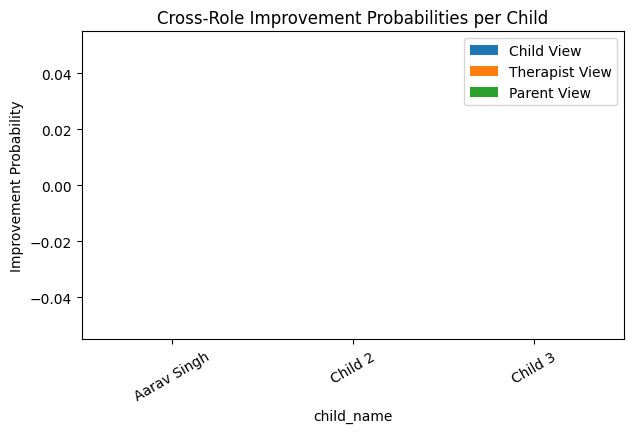

In [ ]:
# === Visualization: Compare Improvement Probabilities Across Roles ===
import matplotlib.pyplot as plt

# Load dashboards back
therapist_df = pd.read_csv("/content/therapist_dashboard.csv")
parent_df = pd.read_csv("/content/parent_dashboard.csv")
child_df = pd.read_csv("/content/child_dashboard.csv")

# Merge core child info
merged = child_df[["child_name","improvement_prob","recommended_next_difficulty"]].merge(
    therapist_df[["child_name","improvement_prob"]].rename(columns={"improvement_prob":"therapist_view"}),
    on="child_name", how="left"
).merge(
    parent_df[["child_name","improvement_prob"]].rename(columns={"improvement_prob":"parent_view"}),
    on="child_name", how="left"
)

print("=== Cross-role Improvement Probabilities ===")
print(merged)

# Plot comparison
merged.set_index("child_name")[["improvement_prob","therapist_view","parent_view"]].plot(
    kind="bar", figsize=(7,4), rot=30
)
plt.ylabel("Improvement Probability")
plt.title("Cross-Role Improvement Probabilities per Child")
plt.legend(["Child View","Therapist View","Parent View"])
plt.show()

In [ ]:
# === Next Step: Export Full Analytics Package (scores, accuracy, attention, predictions) ===
analytics = q("""
SELECT u.full_name AS child_name,
       c.diagnosis,
       s.session_id,
       s.started_at,
       ROUND(AVG(sr.score),2) AS avg_score,
       ROUND(AVG(sr.accuracy),2) AS avg_accuracy,
       ROUND(AVG(ep.attention_idx),2) AS mean_attention,
       m.pred_improvement,
       ROUND(m.pred_improvement_prob,2) AS improvement_prob,
       m.recommended_next_difficulty
FROM sessions s
JOIN child_profiles c ON s.child_id = c.child_id
JOIN users u ON u.user_id = c.user_id
LEFT JOIN session_results sr ON sr.session_id = s.session_id
LEFT JOIN eeg_recordings e ON e.session_id = s.session_id
LEFT JOIN eeg_epochs ep ON ep.eeg_id = e.eeg_id
LEFT JOIN ml_features m ON m.session_id = s.session_id
GROUP BY u.full_name, s.session_id
ORDER BY u.full_name, s.started_at;
""")

print("=== Full Analytics Data ===")
print(analytics.head(10))

# Export to CSV for BI tools
out_path = "/content/full_analytics.csv"
analytics.to_csv(out_path, index=False)
print(f"✅ Exported full analytics to {out_path}")

=== Full Analytics Data ===
    child_name                    diagnosis  session_id           started_at  \
0  Aarav Singh  ASD - needs attention tasks           1  2025-07-01 10:00:00   
1  Aarav Singh  ASD - needs attention tasks           2  2025-07-03 09:00:00   
2  Aarav Singh  ASD - needs attention tasks           3  2025-07-05 11:00:00   
3  Aarav Singh  ASD - needs attention tasks           4  2025-07-07 09:00:00   
4  Aarav Singh  ASD - needs attention tasks           5  2025-07-09 11:00:00   
5  Aarav Singh  ASD - needs attention tasks           6  2025-07-11 09:00:00   
6  Aarav Singh  ASD - needs attention tasks           7  2025-07-13 11:00:00   
7  Aarav Singh  ASD - needs attention tasks           8  2025-07-15 11:00:00   
8  Aarav Singh  ASD - needs attention tasks           9  2025-07-17 10:00:00   
9  Aarav Singh  ASD - needs attention tasks          10  2025-07-19 11:00:00   

   avg_score  avg_accuracy  mean_attention  pred_improvement  \
0       0.75          0.66 

In [ ]:
# === Fixed Child-level summary ===
child_summary = q("""
SELECT u.full_name AS child_name,
       COUNT(DISTINCT s.session_id) AS total_sessions,
       ROUND(AVG(m.avg_score),2) AS overall_avg_score,
       ROUND(AVG(m.avg_accuracy),2) AS overall_avg_accuracy,
       ROUND(AVG(m.mean_attention),2) AS overall_attention,
       ROUND(AVG(m.pred_improvement_prob),2) AS avg_improvement_prob
FROM ml_features m
JOIN child_profiles c ON m.child_id = c.child_id
JOIN users u ON u.user_id = c.user_id
JOIN sessions s ON s.session_id = m.session_id
GROUP BY u.full_name
ORDER BY overall_avg_score DESC;
""")

print("=== Child Summary for Power BI ===")
print(child_summary)

# === Task-level performance summary remains unchanged ===
task_summary = q("""
SELECT ct.name AS task,
       ROUND(AVG(sr.score),2) AS avg_score,
       ROUND(AVG(sr.accuracy),2) AS avg_accuracy,
       COUNT(DISTINCT sr.session_id) AS sessions_count
FROM session_results sr
JOIN cognitive_tasks ct ON ct.task_id = sr.task_id
GROUP BY ct.name
ORDER BY avg_score DESC;
""")

print("\n=== Task Summary for Power BI ===")
print(task_summary)

# Export both summaries
child_summary.to_csv("/content/child_summary.csv", index=False)
task_summary.to_csv("/content/task_summary.csv", index=False)
print("✅ Exported child_summary.csv and task_summary.csv for BI tools")

=== Child Summary for Power BI ===
    child_name  total_sessions  overall_avg_score  overall_avg_accuracy  \
0      Child 2              30               0.74                  0.64   
1      Child 3              30               0.73                  0.64   
2  Aarav Singh              30               0.73                  0.63   

   overall_attention  avg_improvement_prob  
0               0.62                  0.40  
1               0.62                  0.42  
2               0.64                  0.44  

=== Task Summary for Power BI ===
               task  avg_score  avg_accuracy  sessions_count
0  Find Differences       0.74          0.64              90
1   Sequence Recall       0.73          0.63              90
2    Problem Solver       0.73          0.63              90
✅ Exported child_summary.csv and task_summary.csv for BI tools


In [ ]:
# === Next Step: Trend Metrics for Power BI (Score Improvement Rate) ===
trend_summary = q("""
WITH session_stats AS (
    SELECT u.full_name AS child_name,
           s.session_id,
           s.started_at,
           ROUND(AVG(sr.score),2) AS avg_score
    FROM sessions s
    JOIN child_profiles c ON s.child_id = c.child_id
    JOIN users u ON u.user_id = c.user_id
    JOIN session_results sr ON sr.session_id = s.session_id
    GROUP BY u.full_name, s.session_id
)
SELECT child_name,
       MIN(started_at) AS first_session_date,
       MAX(started_at) AS last_session_date,
       MIN(avg_score) AS min_score,
       MAX(avg_score) AS max_score,
       ROUND((MAX(avg_score) - MIN(avg_score)),2) AS score_improvement
FROM session_stats
GROUP BY child_name
ORDER BY score_improvement DESC;
""")

print("=== Score Improvement Trend Summary ===")
print(trend_summary)

# Export for Power BI
out_path = "/content/trend_summary.csv"
trend_summary.to_csv(out_path, index=False)
print(f"✅ Exported trend_summary.csv for BI tools")

=== Score Improvement Trend Summary ===
    child_name   first_session_date    last_session_date  min_score  \
0  Aarav Singh  2025-07-01 10:00:00  2025-08-28 10:00:00       0.56   
1      Child 2  2025-07-01 11:00:00  2025-08-28 10:00:00       0.63   
2      Child 3  2025-07-01 09:00:00  2025-08-28 10:00:00       0.65   

   max_score  score_improvement  
0       0.90               0.34  
1       0.87               0.24  
2       0.85               0.20  
✅ Exported trend_summary.csv for BI tools


=== Attention vs Performance Correlation ===
    child_name  avg_score  avg_accuracy  avg_attention
0  Aarav Singh       0.73          0.63           0.64
1      Child 2       0.74          0.64           0.62
2      Child 3       0.73          0.64           0.62

Correlation Matrix:
               avg_score  avg_accuracy  avg_attention
avg_score            1.0           0.5           -0.5
avg_accuracy         0.5           1.0           -1.0
avg_attention       -0.5          -1.0            1.0


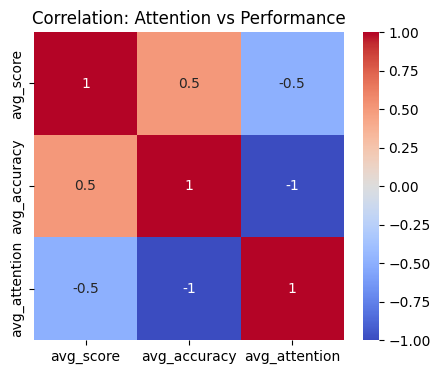

✅ Exported attention_performance.csv for BI tools


In [ ]:
# === Next Step: Attention vs. Performance Correlation Analysis ===
attention_perf = q("""
SELECT u.full_name AS child_name,
       ROUND(AVG(sr.score),2) AS avg_score,
       ROUND(AVG(sr.accuracy),2) AS avg_accuracy,
       ROUND(AVG(ep.attention_idx),2) AS avg_attention
FROM sessions s
JOIN child_profiles c ON s.child_id = c.child_id
JOIN users u ON u.user_id = c.user_id
JOIN session_results sr ON sr.session_id = s.session_id
JOIN eeg_recordings e ON e.session_id = s.session_id
JOIN eeg_epochs ep ON ep.eeg_id = e.eeg_id
GROUP BY u.full_name;
""")

print("=== Attention vs Performance Correlation ===")
print(attention_perf)

# Correlation matrix
corr = attention_perf[["avg_score","avg_accuracy","avg_attention"]].corr()
print("\nCorrelation Matrix:")
print(corr)

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation: Attention vs Performance")
plt.show()

# Export
out_path = "/content/attention_performance.csv"
attention_perf.to_csv(out_path, index=False)
print(f"✅ Exported attention_performance.csv for BI tools")

=== Time Series Data (first 10 rows) ===
    child_name           started_at  avg_score
0  Aarav Singh  2025-07-01 10:00:00       0.75
1  Aarav Singh  2025-07-03 09:00:00       0.82
2  Aarav Singh  2025-07-05 11:00:00       0.90
3  Aarav Singh  2025-07-07 09:00:00       0.66
4  Aarav Singh  2025-07-09 11:00:00       0.77
5  Aarav Singh  2025-07-11 09:00:00       0.75
6  Aarav Singh  2025-07-13 11:00:00       0.62
7  Aarav Singh  2025-07-15 11:00:00       0.67
8  Aarav Singh  2025-07-17 10:00:00       0.75
9  Aarav Singh  2025-07-19 11:00:00       0.65


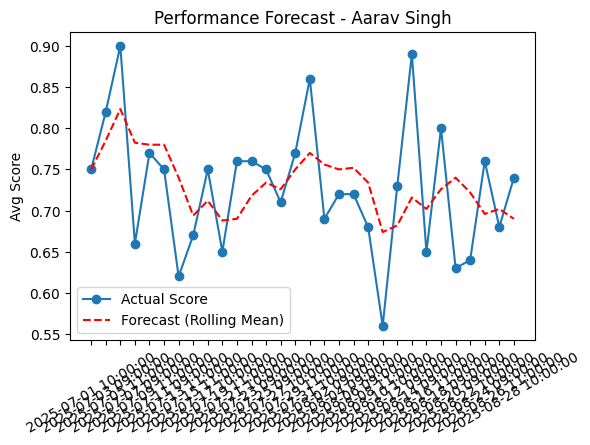

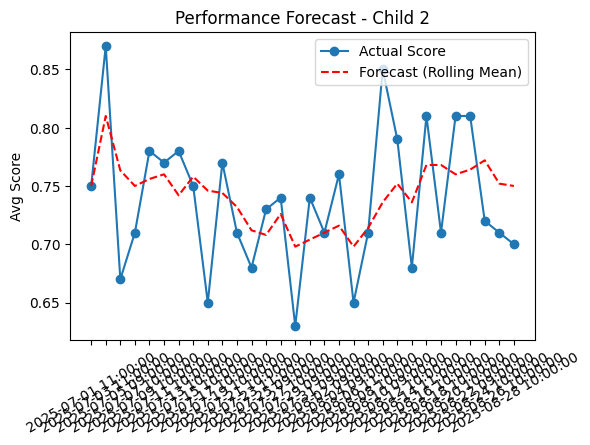

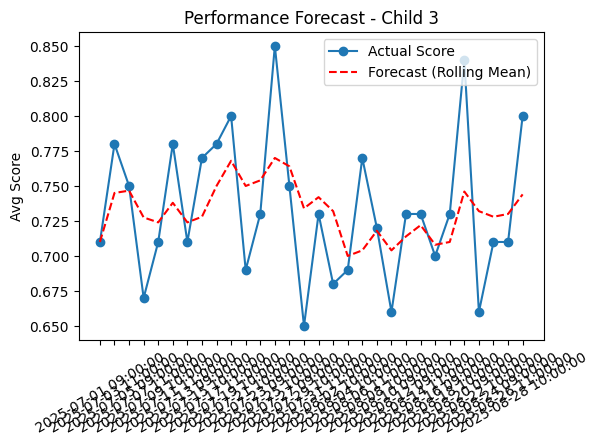

✅ Exported time_series_forecast.csv for BI tools


In [ ]:
# === Next Step: Session-Level Performance Forecasting (Time Series) ===
# Load time series per child
ts_data = q("""
SELECT u.full_name AS child_name,
       s.started_at,
       ROUND(AVG(sr.score),2) AS avg_score
FROM sessions s
JOIN child_profiles c ON s.child_id = c.child_id
JOIN users u ON u.user_id = c.user_id
JOIN session_results sr ON sr.session_id = s.session_id
GROUP BY u.full_name, s.started_at
ORDER BY u.full_name, s.started_at;
""")

print("=== Time Series Data (first 10 rows) ===")
print(ts_data.head(10))

# Forecast trend using rolling mean
import matplotlib.pyplot as plt

for child, dfc in ts_data.groupby("child_name"):
    dfc = dfc.sort_values("started_at")
    dfc["rolling_mean"] = dfc["avg_score"].rolling(window=5, min_periods=1).mean()

    plt.figure(figsize=(6,4))
    plt.plot(dfc["started_at"], dfc["avg_score"], marker="o", label="Actual Score")
    plt.plot(dfc["started_at"], dfc["rolling_mean"], linestyle="--", color="red", label="Forecast (Rolling Mean)")
    plt.xticks(rotation=30)
    plt.title(f"Performance Forecast - {child}")
    plt.ylabel("Avg Score")
    plt.legend()
    plt.show()

# Export time series data
out_path = "/content/time_series_forecast.csv"
ts_data.to_csv(out_path, index=False)
print(f"✅ Exported time_series_forecast.csv for BI tools")

=== Engagement Summary ===
    child_name  total_sessions  avg_session_minutes
0      Child 3              30                 30.0
1      Child 2              30                 30.0
2  Aarav Singh              30                 30.0


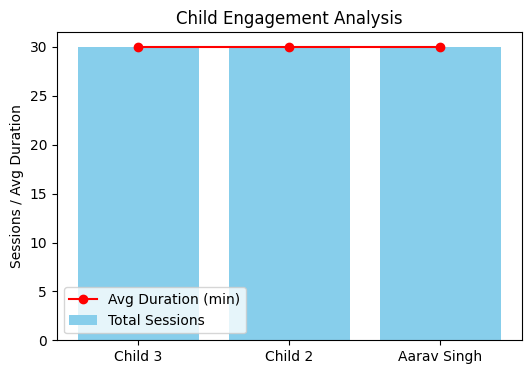

✅ Exported engagement_summary.csv for BI tools


In [ ]:
# === Next Step: Engagement Analysis (Sessions per Child & Avg Duration) ===
engagement = q("""
SELECT u.full_name AS child_name,
       COUNT(DISTINCT s.session_id) AS total_sessions,
       ROUND(AVG(JULIANDAY(s.ended_at) - JULIANDAY(s.started_at)) * 24*60, 2) AS avg_session_minutes
FROM sessions s
JOIN child_profiles c ON s.child_id = c.child_id
JOIN users u ON u.user_id = c.user_id
GROUP BY u.full_name
ORDER BY total_sessions DESC;
""")

print("=== Engagement Summary ===")
print(engagement)

# --- Plot Engagement ---
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(engagement["child_name"], engagement["total_sessions"], color="skyblue", label="Total Sessions")
plt.plot(engagement["child_name"], engagement["avg_session_minutes"], marker="o", color="red", label="Avg Duration (min)")
plt.title("Child Engagement Analysis")
plt.ylabel("Sessions / Avg Duration")
plt.legend()
plt.show()

# Export
out_path = "/content/engagement_summary.csv"
engagement.to_csv(out_path, index=False)
print(f"✅ Exported engagement_summary.csv for BI tools")

=== Domain-wise Performance ===
    child_name     domain  avg_score  avg_accuracy  attempts
0  Aarav Singh  ATTENTION       0.75          0.65        60
1  Aarav Singh      LOGIC       0.74          0.64        30
2  Aarav Singh     MEMORY       0.70          0.60        60
3      Child 2  ATTENTION       0.74          0.64        60
4      Child 2      LOGIC       0.73          0.63        30
5      Child 2     MEMORY       0.74          0.64        60
6      Child 3  ATTENTION       0.71          0.62        60
7      Child 3      LOGIC       0.72          0.63        30
8      Child 3     MEMORY       0.76          0.66        60


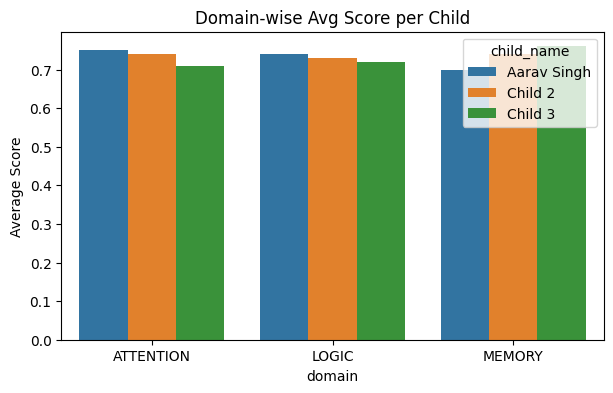

✅ Exported domain_performance.csv for BI tools


In [ ]:
# === Next Step: Domain-wise Performance Analysis ===
domain_perf = q("""
SELECT u.full_name AS child_name,
       ct.domain,
       ROUND(AVG(sr.score),2) AS avg_score,
       ROUND(AVG(sr.accuracy),2) AS avg_accuracy,
       COUNT(sr.result_id) AS attempts
FROM session_results sr
JOIN sessions s ON sr.session_id = s.session_id
JOIN child_profiles c ON s.child_id = c.child_id
JOIN users u ON u.user_id = c.user_id
JOIN cognitive_tasks ct ON sr.task_id = ct.task_id
GROUP BY u.full_name, ct.domain
ORDER BY u.full_name, ct.domain;
""")

print("=== Domain-wise Performance ===")
print(domain_perf)

# --- Plot Domain-wise Performance ---
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
sns.barplot(data=domain_perf, x="domain", y="avg_score", hue="child_name")
plt.title("Domain-wise Avg Score per Child")
plt.ylabel("Average Score")
plt.show()

# Export
out_path = "/content/domain_performance.csv"
domain_perf.to_csv(out_path, index=False)
print(f"✅ Exported domain_performance.csv for BI tools")

=== Difficulty Progression ===
     child_name  difficulty  avg_score  avg_accuracy  attempts
0   Aarav Singh           1       0.75          0.65        32
1   Aarav Singh           2       0.75          0.64        25
2   Aarav Singh           3       0.69          0.59        33
3   Aarav Singh           4       0.72          0.62        24
4   Aarav Singh           5       0.73          0.64        36
5       Child 2           1       0.74          0.64        29
6       Child 2           2       0.75          0.65        30
7       Child 2           3       0.74          0.63        21
8       Child 2           4       0.74          0.64        37
9       Child 2           5       0.73          0.62        33
10      Child 3           1       0.74          0.64        38
11      Child 3           2       0.73          0.63        29
12      Child 3           3       0.73          0.64        24
13      Child 3           4       0.75          0.65        29
14      Child 3         

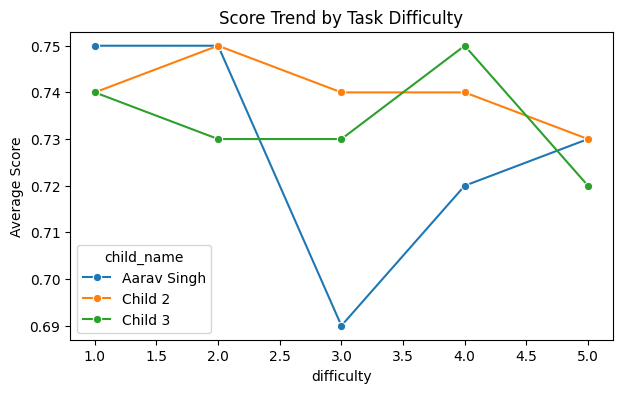

✅ Exported difficulty_trend.csv for BI tools


In [ ]:
# === Next Step: Difficulty Progression Analysis ===
difficulty_trend = q("""
SELECT u.full_name AS child_name,
       sr.difficulty,
       ROUND(AVG(sr.score),2) AS avg_score,
       ROUND(AVG(sr.accuracy),2) AS avg_accuracy,
       COUNT(sr.result_id) AS attempts
FROM session_results sr
JOIN sessions s ON sr.session_id = s.session_id
JOIN child_profiles c ON s.child_id = c.child_id
JOIN users u ON u.user_id = c.user_id
GROUP BY u.full_name, sr.difficulty
ORDER BY u.full_name, sr.difficulty;
""")

print("=== Difficulty Progression ===")
print(difficulty_trend)

# --- Plot Difficulty vs Score ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,4))
sns.lineplot(data=difficulty_trend, x="difficulty", y="avg_score", hue="child_name", marker="o")
plt.title("Score Trend by Task Difficulty")
plt.ylabel("Average Score")
plt.show()

# Export
out_path = "/content/difficulty_trend.csv"
difficulty_trend.to_csv(out_path, index=False)
print(f"✅ Exported difficulty_trend.csv for BI tools")

In [ ]:
# ============================================================
# CELL 8: GAME DB SCHEMA
# Adding Game Tables to existing ccrp_demo.db
# ============================================================

import sqlite3
import pandas as pd

# === Reconnect to same DB ===
db_path = "/content/ccrp_demo.db"
con = sqlite3.connect(db_path)
con.execute("PRAGMA foreign_keys = ON;")

# === Verify basic DB tables still exist ===
print("=== Existing Tables Before Adding Game Schema ===")
print(pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';", con
))

# === GAME SCHEMA ===
game_schema_sql = """
PRAGMA foreign_keys = ON;

-- -------------------------------------------------------
-- TABLE 1: game_catalog
-- Master list of all 3 games
-- Links to cognitive_tasks in basic DB
-- -------------------------------------------------------
CREATE TABLE IF NOT EXISTS game_catalog (
    game_id         INTEGER PRIMARY KEY,
    game_name       TEXT NOT NULL UNIQUE,
    cognitive_domain TEXT NOT NULL,
    description     TEXT,
    max_levels      INTEGER NOT NULL,
    task_id         INTEGER,
    FOREIGN KEY(task_id) REFERENCES cognitive_tasks(task_id)
);

-- -------------------------------------------------------
-- TABLE 2: game_sessions
-- Each time a child sits down to play a game
-- Links to child_profiles and sessions in basic DB
-- -------------------------------------------------------
CREATE TABLE IF NOT EXISTS game_sessions (
    game_session_id INTEGER PRIMARY KEY,
    child_id        INTEGER NOT NULL,
    game_id         INTEGER NOT NULL,
    session_id      INTEGER,
    started_at      DATETIME NOT NULL,
    ended_at        DATETIME,
    total_levels_played INTEGER DEFAULT 0,
    total_score     REAL DEFAULT 0,
    FOREIGN KEY(child_id)   REFERENCES child_profiles(child_id),
    FOREIGN KEY(game_id)    REFERENCES game_catalog(game_id),
    FOREIGN KEY(session_id) REFERENCES sessions(session_id)
);

-- -------------------------------------------------------
-- TABLE 3: game_level_results
-- Result of each individual level in a game session
-- Common across all 3 games
-- -------------------------------------------------------
CREATE TABLE IF NOT EXISTS game_level_results (
    level_result_id     INTEGER PRIMARY KEY,
    game_session_id     INTEGER NOT NULL,
    level_number        INTEGER NOT NULL,
    score               REAL,
    accuracy            REAL,
    time_taken_seconds  INTEGER,
    completed           INTEGER DEFAULT 0,
    FOREIGN KEY(game_session_id) REFERENCES game_sessions(game_session_id)
);

-- -------------------------------------------------------
-- TABLE 4: card_memory_details
-- Specific details for CardRememberGame only
-- -------------------------------------------------------
CREATE TABLE IF NOT EXISTS card_memory_details (
    detail_id       INTEGER PRIMARY KEY,
    level_result_id INTEGER NOT NULL UNIQUE,
    theme_name      TEXT,
    moves_taken     INTEGER,
    pairs_total     INTEGER DEFAULT 6,
    memorize_time_used INTEGER,
    FOREIGN KEY(level_result_id) REFERENCES game_level_results(level_result_id)
);

-- -------------------------------------------------------
-- TABLE 5: word_circle_details
-- Specific details for WordCircleGame only
-- -------------------------------------------------------
CREATE TABLE IF NOT EXISTS word_circle_details (
    detail_id       INTEGER PRIMARY KEY,
    level_result_id INTEGER NOT NULL UNIQUE,
    words_found     INTEGER,
    total_words     INTEGER,
    hints_used      INTEGER DEFAULT 0,
    mistakes_count  INTEGER DEFAULT 0,
    duplicates_count INTEGER DEFAULT 0,
    letters_count   INTEGER,
    FOREIGN KEY(level_result_id) REFERENCES game_level_results(level_result_id)
);

-- -------------------------------------------------------
-- TABLE 6: kids_puzzle_details
-- Specific details for KidsPuzzleGame only
-- -------------------------------------------------------
CREATE TABLE IF NOT EXISTS kids_puzzle_details (
    detail_id       INTEGER PRIMARY KEY,
    level_result_id INTEGER NOT NULL UNIQUE,
    category_name   TEXT,
    items_matched   INTEGER,
    items_total     INTEGER DEFAULT 4,
    FOREIGN KEY(level_result_id) REFERENCES game_level_results(level_result_id)
);
"""

# === Execute Game Schema ===
con.executescript(game_schema_sql)
con.commit()
print("\n✅ Game tables created successfully!")

# === Verify ALL tables now (basic + game) ===
print("\n=== All Tables After Adding Game Schema ===")
all_tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';", con
)
print(all_tables)

# === Show structure of each new game table ===
game_tables = [
    'game_catalog',
    'game_sessions',
    'game_level_results',
    'card_memory_details',
    'word_circle_details',
    'kids_puzzle_details'
]

print("\n=== Structure of New Game Tables ===")
for table in game_tables:
    print(f"\n--- {table} ---")
    print(pd.read_sql_query(f"PRAGMA table_info({table});", con))

# === Verify Foreign Key Links ===
print("\n=== Foreign Key Verification ===")
for table in game_tables:
    fk = pd.read_sql_query(f"PRAGMA foreign_key_list({table});", con)
    if not fk.empty:
        print(f"\n{table} → Foreign Keys:")
        print(fk[['table','from','to']])
    else:
        print(f"\n{table} → No foreign keys (detail table)")

print("\n=== Cell 8 Complete ===")
print("Basic DB tables:  14")
print("New Game tables:   6")
print("Total tables:     20")
print("\nReady for Cell 9: Game Seed Data")

=== Existing Tables Before Adding Game Schema ===
                  name
0                roles
1                users
2           user_roles
3       child_profiles
4   therapist_profiles
5      parent_profiles
6    parent_child_link
7      cognitive_tasks
8             sessions
9      session_results
10      eeg_recordings
11          eeg_epochs
12     therapist_notes
13         ml_features
14     sqlite_sequence

✅ Game tables created successfully!

=== All Tables After Adding Game Schema ===
                   name
0                 roles
1                 users
2            user_roles
3        child_profiles
4    therapist_profiles
5       parent_profiles
6     parent_child_link
7       cognitive_tasks
8              sessions
9       session_results
10       eeg_recordings
11           eeg_epochs
12      therapist_notes
13          ml_features
14      sqlite_sequence
15         game_catalog
16        game_sessions
17   game_level_results
18  card_memory_details
19  word_circle_deta

In [ ]:
# GAME SEED DATA + SYNTHETIC DATA GENERATOR
# Populates all 6 game tables with realistic data
# For all 3 children across multiple game sessions

import sqlite3
import pandas as pd
import random
import datetime

db_path = "/content/ccrp_demo.db"
con = sqlite3.connect(db_path)
con.execute("PRAGMA foreign_keys = ON;")
cursor = con.cursor()

# ============================================================
# STEP 1: SEED GAME CATALOG
# 3 games linked to cognitive_tasks in basic DB
# ============================================================

# First check existing task_ids
tasks = pd.read_sql_query("SELECT task_id, name, domain FROM cognitive_tasks;", con)
print("=== Existing Cognitive Tasks ===")
print(tasks)

# Get task_ids for linking
task_map = {row['name']: row['task_id'] for _, row in tasks.iterrows()}

# Insert game catalog
game_catalog_sql = """
INSERT OR IGNORE INTO game_catalog
    (game_id, game_name, cognitive_domain, description, max_levels, task_id)
VALUES
    (1, 'CardMemoryGame', 'MEMORY',
     'Match pairs of cards to train visual memory and concentration',
     100,
     (SELECT task_id FROM cognitive_tasks WHERE name='Sequence Recall')),

    (2, 'WordCircleGame', 'ATTENTION',
     'Connect letters to form words, training attention and language skills',
     100,
     (SELECT task_id FROM cognitive_tasks WHERE name='Find Differences')),

    (3, 'KidsPuzzleGame', 'ATTENTION',
     'Drag and drop matching items to train visual attention and recognition',
     50,
     (SELECT task_id FROM cognitive_tasks WHERE name='Find Differences'));
"""
con.executescript(game_catalog_sql)
con.commit()

print("\n=== Game Catalog ===")
print(pd.read_sql_query("SELECT * FROM game_catalog;", con))

# ============================================================
# STEP 2: CONFIGURATION
# Realistic data based on actual game code
# ============================================================

# CardMemoryGame - 20 themes from actual game code
CARD_THEMES = [
    "Egypt", "Space", "Jungle", "Ocean", "Candy",
    "Tech", "Medieval", "Art", "Fruits", "Animals",
    "Weather", "Sports", "Music", "Vehicles", "Gems",
    "Mythology", "Garden", "School", "Winter", "Party"
]

# WordCircleGame - categories from actual game code
WORD_CATEGORIES = [
    "3-letter", "4-letter", "5-letter",
    "6-letter", "7-letter", "8-letter"
]

# KidsPuzzleGame - 50 categories from actual game code
PUZZLE_CATEGORIES = [
    "Shapes", "Animals", "Fruits", "Vegetables", "Vehicles",
    "Colors", "Weather", "Numbers", "Space", "Ocean",
    "Farm", "Clothes", "House", "Sports", "School",
    "Nature", "FastFood", "Insects", "Birds", "Music",
    "Garden", "Emotions", "Jobs", "Body", "Tools",
    "Toys", "Travel", "Seasons", "Desserts", "Drinks",
    "Kitchen", "Furniture", "Bathroom", "Gardening", "Woodland",
    "Safari", "Arctic", "Desert", "Dinos", "Fantasy",
    "AirTravel", "SeaTravel", "LandTravel", "Hardware", "Office",
    "Electronics", "Art", "Science", "Math", "Camping"
]

# Get children from DB
children = pd.read_sql_query(
    "SELECT child_id FROM child_profiles;", con
)
child_ids = children['child_id'].tolist()
print(f"\n=== Generating data for {len(child_ids)} children ===")
print(f"Child IDs: {child_ids}")

# Get existing session_ids from basic DB
sessions_df = pd.read_sql_query(
    "SELECT session_id, child_id, started_at FROM sessions ORDER BY child_id, started_at;",
    con
)
print(f"\nTotal existing sessions: {len(sessions_df)}")

# ============================================================
# STEP 3: SYNTHETIC DATA GENERATOR
# ============================================================

NUM_GAME_SESSIONS_PER_CHILD = 10  # 10 game sessions per child per game
start_date = datetime.datetime(2025, 7, 1, 9, 0, 0)

total_game_sessions = 0
total_level_results = 0
total_card_details = 0
total_word_details = 0
total_kids_details = 0

for child_id in child_ids:

    # Get this child's session_ids from basic DB
    child_sessions = sessions_df[
        sessions_df['child_id'] == child_id
    ]['session_id'].tolist()

    # --------------------------------------------------------
    # GAME 1: CardMemoryGame (game_id = 1)
    # --------------------------------------------------------
    for gs in range(NUM_GAME_SESSIONS_PER_CHILD):

        # Game session timing
        g_start = start_date + datetime.timedelta(
            days=gs * 3,
            hours=random.randint(9, 17)
        )
        g_end = g_start + datetime.timedelta(minutes=random.randint(20, 45))

        # How many levels played in this session (improves over time)
        levels_played = min(5 + gs, 20)  # starts at 5, grows with sessions

        # Running score total
        session_score = 0.0

        # Link to basic DB session if available
        linked_session = child_sessions[gs] if gs < len(child_sessions) else None

        # Insert game_session
        cursor.execute("""
            INSERT INTO game_sessions
                (child_id, game_id, session_id, started_at, ended_at,
                 total_levels_played, total_score)
            VALUES (?,1,?,?,?,?,?)
        """, (child_id, linked_session,
              g_start.isoformat(), g_end.isoformat(),
              levels_played, 0.0))
        game_session_id = cursor.lastrowid
        total_game_sessions += 1

        for lvl in range(1, levels_played + 1):

            # Score improves as sessions progress
            base_score = 0.5 + (gs * 0.02) + random.uniform(-0.1, 0.1)
            score = round(min(max(base_score, 0.3), 1.0), 2)
            accuracy = round(min(max(score - random.uniform(0.02, 0.1), 0.2), 1.0), 2)
            time_taken = random.randint(30, 180)
            completed = 1 if score > 0.5 else 0

            # Insert level result
            cursor.execute("""
                INSERT INTO game_level_results
                    (game_session_id, level_number, score, accuracy,
                     time_taken_seconds, completed)
                VALUES (?,?,?,?,?,?)
            """, (game_session_id, lvl, score, accuracy, time_taken, completed))
            level_result_id = cursor.lastrowid
            session_score += score
            total_level_results += 1

            # Theme cycles every 5 levels (matches actual game logic)
            theme_index = (lvl - 1) // 5 % len(CARD_THEMES)
            theme = CARD_THEMES[theme_index]

            # Moves: perfect = 6, realistic = 6 to 20
            min_moves = 6
            max_moves = max(6, 20 - gs)  # improves over sessions
            moves = random.randint(min_moves, max_moves)

            # Insert card memory details
            cursor.execute("""
                INSERT INTO card_memory_details
                    (level_result_id, theme_name, moves_taken,
                     pairs_total, memorize_time_used)
                VALUES (?,?,?,6,?)
            """, (level_result_id, theme, moves,
                  random.randint(1000, 2000)))
            total_card_details += 1

        # Update total score in game_session
        cursor.execute("""
            UPDATE game_sessions
            SET total_score = ?
            WHERE game_session_id = ?
        """, (round(session_score, 2), game_session_id))

    # --------------------------------------------------------
    # GAME 2: WordCircleGame (game_id = 2)
    # --------------------------------------------------------
    for gs in range(NUM_GAME_SESSIONS_PER_CHILD):

        g_start = start_date + datetime.timedelta(
            days=gs * 3 + 1,
            hours=random.randint(9, 17)
        )
        g_end = g_start + datetime.timedelta(minutes=random.randint(15, 40))

        levels_played = min(4 + gs, 15)
        session_score = 0.0
        linked_session = child_sessions[gs + 10] if (gs + 10) < len(child_sessions) else None

        cursor.execute("""
            INSERT INTO game_sessions
                (child_id, game_id, session_id, started_at, ended_at,
                 total_levels_played, total_score)
            VALUES (?,2,?,?,?,?,?)
        """, (child_id, linked_session,
              g_start.isoformat(), g_end.isoformat(),
              levels_played, 0.0))
        game_session_id = cursor.lastrowid
        total_game_sessions += 1

        for lvl in range(1, levels_played + 1):

            base_score = 0.45 + (gs * 0.025) + random.uniform(-0.1, 0.1)
            score = round(min(max(base_score, 0.2), 1.0), 2)
            accuracy = round(min(max(score - random.uniform(0.02, 0.12), 0.1), 1.0), 2)
            time_taken = random.randint(20, 120)
            completed = 1 if score > 0.45 else 0

            cursor.execute("""
                INSERT INTO game_level_results
                    (game_session_id, level_number, score, accuracy,
                     time_taken_seconds, completed)
                VALUES (?,?,?,?,?,?)
            """, (game_session_id, lvl, score, accuracy, time_taken, completed))
            level_result_id = cursor.lastrowid
            session_score += score
            total_level_results += 1

            # Letter count increases with level (matches actual game)
            if lvl <= 20:
                letters = random.randint(3, 4)
            elif lvl <= 50:
                letters = random.randint(5, 6)
            else:
                letters = random.randint(6, 10)

            # Words found improves over sessions
            total_words = random.randint(2, 6)
            words_found = random.randint(
                max(1, total_words - 2),
                total_words
            )

            cursor.execute("""
                INSERT INTO word_circle_details
                    (level_result_id, words_found, total_words,
                     hints_used, mistakes_count, duplicates_count,
                     letters_count)
                VALUES (?,?,?,?,?,?,?)
            """, (level_result_id,
                  words_found, total_words,
                  random.randint(0, 3),
                  random.randint(0, 5),
                  random.randint(0, 3),
                  letters))
            total_word_details += 1

        cursor.execute("""
            UPDATE game_sessions SET total_score = ?
            WHERE game_session_id = ?
        """, (round(session_score, 2), game_session_id))

    # --------------------------------------------------------
    # GAME 3: KidsPuzzleGame (game_id = 3)
    # --------------------------------------------------------
    for gs in range(NUM_GAME_SESSIONS_PER_CHILD):

        g_start = start_date + datetime.timedelta(
            days=gs * 3 + 2,
            hours=random.randint(9, 17)
        )
        g_end = g_start + datetime.timedelta(minutes=random.randint(10, 30))

        levels_played = min(3 + gs, 12)
        session_score = 0.0
        linked_session = child_sessions[gs + 20] if (gs + 20) < len(child_sessions) else None

        cursor.execute("""
            INSERT INTO game_sessions
                (child_id, game_id, session_id, started_at, ended_at,
                 total_levels_played, total_score)
            VALUES (?,3,?,?,?,?,?)
        """, (child_id, linked_session,
              g_start.isoformat(), g_end.isoformat(),
              levels_played, 0.0))
        game_session_id = cursor.lastrowid
        total_game_sessions += 1

        for lvl in range(1, levels_played + 1):

            base_score = 0.55 + (gs * 0.02) + random.uniform(-0.08, 0.08)
            score = round(min(max(base_score, 0.3), 1.0), 2)
            accuracy = round(min(max(score - random.uniform(0.01, 0.08), 0.2), 1.0), 2)
            time_taken = random.randint(15, 90)
            completed = 1 if score > 0.5 else 0

            cursor.execute("""
                INSERT INTO game_level_results
                    (game_session_id, level_number, score, accuracy,
                     time_taken_seconds, completed)
                VALUES (?,?,?,?,?,?)
            """, (game_session_id, lvl, score, accuracy, time_taken, completed))
            level_result_id = cursor.lastrowid
            session_score += score
            total_level_results += 1

            # Category cycles through puzzle levels
            category = PUZZLE_CATEGORIES[(lvl - 1) % len(PUZZLE_CATEGORIES)]

            # Items matched improves over sessions
            items_matched = random.randint(
                max(1, 4 - (2 if gs < 3 else 0)),
                4
            )

            cursor.execute("""
                INSERT INTO kids_puzzle_details
                    (level_result_id, category_name,
                     items_matched, items_total)
                VALUES (?,?,?,4)
            """, (level_result_id, category, items_matched))
            total_kids_details += 1

        cursor.execute("""
            UPDATE game_sessions SET total_score = ?
            WHERE game_session_id = ?
        """, (round(session_score, 2), game_session_id))

con.commit()

# ============================================================
# STEP 4: SUMMARY
# ============================================================
print("\n" + "="*50)
print("✅ SYNTHETIC GAME DATA GENERATED SUCCESSFULLY")
print("="*50)
print(f"Game sessions created : {total_game_sessions}")
print(f"Level results created : {total_level_results}")
print(f"Card memory details   : {total_card_details}")
print(f"Word circle details   : {total_word_details}")
print(f"Kids puzzle details   : {total_kids_details}")

# ============================================================
# STEP 5: VERIFICATION QUERIES
# ============================================================
print("\n=== Game Catalog ===")
print(pd.read_sql_query("SELECT * FROM game_catalog;", con))

print("\n=== Game Sessions Summary ===")
print(pd.read_sql_query("""
SELECT gc.game_name,
       COUNT(gs.game_session_id) AS total_sessions,
       ROUND(AVG(gs.total_levels_played),1) AS avg_levels,
       ROUND(AVG(gs.total_score),2) AS avg_total_score
FROM game_sessions gs
JOIN game_catalog gc ON gc.game_id = gs.game_id
GROUP BY gc.game_name;
""", con))

print("\n=== Level Results Summary ===")
print(pd.read_sql_query("""
SELECT gc.game_name,
       COUNT(glr.level_result_id) AS total_levels,
       ROUND(AVG(glr.score),2) AS avg_score,
       ROUND(AVG(glr.accuracy),2) AS avg_accuracy,
       ROUND(AVG(glr.time_taken_seconds),1) AS avg_time_sec,
       SUM(glr.completed) AS levels_completed
FROM game_level_results glr
JOIN game_sessions gs ON gs.game_session_id = glr.game_session_id
JOIN game_catalog gc ON gc.game_id = gs.game_id
GROUP BY gc.game_name;
""", con))

print("\n=== Card Memory Details Sample ===")
print(pd.read_sql_query("""
SELECT gc.game_name, glr.level_number,
       cmd.theme_name, cmd.moves_taken,
       cmd.pairs_total, glr.score
FROM card_memory_details cmd
JOIN game_level_results glr ON glr.level_result_id = cmd.level_result_id
JOIN game_sessions gs ON gs.game_session_id = glr.game_session_id
JOIN game_catalog gc ON gc.game_id = gs.game_id
LIMIT 10;
""", con))

print("\n=== Word Circle Details Sample ===")
print(pd.read_sql_query("""
SELECT gc.game_name, glr.level_number,
       wcd.words_found, wcd.total_words,
       wcd.hints_used, wcd.mistakes_count,
       wcd.letters_count, glr.score
FROM word_circle_details wcd
JOIN game_level_results glr ON glr.level_result_id = wcd.level_result_id
JOIN game_sessions gs ON gs.game_session_id = glr.game_session_id
JOIN game_catalog gc ON gc.game_id = gs.game_id
LIMIT 10;
""", con))

print("\n=== Kids Puzzle Details Sample ===")
print(pd.read_sql_query("""
SELECT gc.game_name, glr.level_number,
       kpd.category_name, kpd.items_matched,
       kpd.items_total, glr.score
FROM kids_puzzle_details kpd
JOIN game_level_results glr ON glr.level_result_id = kpd.level_result_id
JOIN game_sessions gs ON gs.game_session_id = glr.game_session_id
JOIN game_catalog gc ON gc.game_id = gs.game_id
LIMIT 10;
""", con))

print("\n=== Child Progress Across All Games ===")
print(pd.read_sql_query("""
SELECT u.full_name AS child_name,
       gc.game_name,
       COUNT(DISTINCT gs.game_session_id) AS sessions_played,
       MAX(glr.level_number) AS highest_level,
       ROUND(AVG(glr.score),2) AS avg_score,
       ROUND(AVG(glr.accuracy),2) AS avg_accuracy,
       SUM(glr.completed) AS levels_completed
FROM game_sessions gs
JOIN game_catalog gc ON gc.game_id = gs.game_id
JOIN game_level_results glr ON glr.game_session_id = gs.game_session_id
JOIN child_profiles cp ON cp.child_id = gs.child_id
JOIN users u ON u.user_id = cp.user_id
GROUP BY u.full_name, gc.game_name
ORDER BY u.full_name, gc.game_name;
""", con))

print("\n=== Cell 9 Complete ===")
print("Ready for Cell 10: Game Queries & Analytics")

=== Existing Cognitive Tasks ===
   task_id              name     domain
0        1  Find Differences  ATTENTION
1        2   Sequence Recall     MEMORY
2        3  Find Differences  ATTENTION
3        4   Sequence Recall     MEMORY
4        5    Problem Solver      LOGIC

=== Game Catalog ===
   game_id       game_name cognitive_domain  \
0        1  CardMemoryGame           MEMORY   
1        2  WordCircleGame        ATTENTION   
2        3  KidsPuzzleGame        ATTENTION   

                                         description  max_levels  task_id  
0  Match pairs of cards to train visual memory an...         100        2  
1  Connect letters to form words, training attent...         100        1  
2  Drag and drop matching items to train visual a...          50        1  

=== Generating data for 3 children ===
Child IDs: [1, 2, 3]

Total existing sessions: 90

✅ SYNTHETIC GAME DATA GENERATED SUCCESSFULLY
Game sessions created : 90
Level results created : 765
Card memory details  

In [ ]:
# ============================================================
# CELL 10: GAME QUERIES & ANALYTICS
# Deep analysis of game performance data
# Role-based views + cross-game insights
# ============================================================

import sqlite3
import pandas as pd

db_path = "/content/ccrp_demo.db"
con = sqlite3.connect(db_path)
con.execute("PRAGMA foreign_keys = ON;")

def q(sql, params=()):
    return pd.read_sql_query(sql, con, params=params)

# ============================================================
# QUERY 1: CHILD OVERALL GAME PERFORMANCE SUMMARY
# ============================================================
print("=" * 55)
print("QUERY 1: Child Overall Game Performance Summary")
print("=" * 55)
print(q("""
SELECT
    u.full_name AS child_name,
    c.diagnosis,
    COUNT(DISTINCT gs.game_session_id) AS total_game_sessions,
    COUNT(glr.level_result_id) AS total_levels_attempted,
    SUM(glr.completed) AS total_levels_completed,
    ROUND(AVG(glr.score), 2) AS overall_avg_score,
    ROUND(AVG(glr.accuracy), 2) AS overall_avg_accuracy,
    ROUND(AVG(glr.time_taken_seconds), 1) AS avg_time_per_level_sec
FROM game_sessions gs
JOIN game_level_results glr ON glr.game_session_id = gs.game_session_id
JOIN child_profiles c ON c.child_id = gs.child_id
JOIN users u ON u.user_id = c.user_id
GROUP BY u.full_name
ORDER BY overall_avg_score DESC;
"""))

# ============================================================
# QUERY 2: PERFORMANCE PER GAME PER CHILD
# ============================================================
print("\n" + "=" * 55)
print("QUERY 2: Performance Per Game Per Child")
print("=" * 55)
print(q("""
SELECT
    u.full_name AS child_name,
    gc.game_name,
    gc.cognitive_domain,
    COUNT(DISTINCT gs.game_session_id) AS sessions_played,
    MAX(glr.level_number) AS highest_level_reached,
    ROUND(AVG(glr.score), 2) AS avg_score,
    ROUND(AVG(glr.accuracy), 2) AS avg_accuracy,
    SUM(glr.completed) AS levels_completed,
    ROUND(AVG(glr.time_taken_seconds), 1) AS avg_time_sec
FROM game_sessions gs
JOIN game_catalog gc ON gc.game_id = gs.game_id
JOIN game_level_results glr ON glr.game_session_id = gs.game_session_id
JOIN child_profiles c ON c.child_id = gs.child_id
JOIN users u ON u.user_id = c.user_id
GROUP BY u.full_name, gc.game_name
ORDER BY u.full_name, gc.game_name;
"""))

# ============================================================
# QUERY 3: CARD MEMORY GAME - THEME PERFORMANCE
# ============================================================
print("\n" + "=" * 55)
print("QUERY 3: Card Memory - Theme Performance")
print("=" * 55)
print(q("""
SELECT
    u.full_name AS child_name,
    cmd.theme_name,
    COUNT(*) AS times_played,
    ROUND(AVG(glr.score), 2) AS avg_score,
    ROUND(AVG(cmd.moves_taken), 1) AS avg_moves,
    MIN(cmd.moves_taken) AS best_moves,
    ROUND(AVG(glr.time_taken_seconds), 1) AS avg_time_sec
FROM card_memory_details cmd
JOIN game_level_results glr ON glr.level_result_id = cmd.level_result_id
JOIN game_sessions gs ON gs.game_session_id = glr.game_session_id
JOIN child_profiles c ON c.child_id = gs.child_id
JOIN users u ON u.user_id = c.user_id
GROUP BY u.full_name, cmd.theme_name
ORDER BY u.full_name, avg_score DESC;
"""))

# ============================================================
# QUERY 4: WORD CIRCLE GAME - WORD FINDING ANALYSIS
# ============================================================
print("\n" + "=" * 55)
print("QUERY 4: Word Circle - Word Finding Analysis")
print("=" * 55)
print(q("""
SELECT
    u.full_name AS child_name,
    wcd.letters_count,
    COUNT(*) AS levels_attempted,
    ROUND(AVG(wcd.words_found * 1.0 / wcd.total_words), 2) AS word_completion_rate,
    ROUND(AVG(wcd.hints_used), 2) AS avg_hints_used,
    ROUND(AVG(wcd.mistakes_count), 2) AS avg_mistakes,
    ROUND(AVG(glr.score), 2) AS avg_score
FROM word_circle_details wcd
JOIN game_level_results glr ON glr.level_result_id = wcd.level_result_id
JOIN game_sessions gs ON gs.game_session_id = glr.game_session_id
JOIN child_profiles c ON c.child_id = gs.child_id
JOIN users u ON u.user_id = c.user_id
GROUP BY u.full_name, wcd.letters_count
ORDER BY u.full_name, wcd.letters_count;
"""))

# ============================================================
# QUERY 5: KIDS PUZZLE GAME - CATEGORY PERFORMANCE
# ============================================================
print("\n" + "=" * 55)
print("QUERY 5: Kids Puzzle - Category Performance")
print("=" * 55)
print(q("""
SELECT
    u.full_name AS child_name,
    kpd.category_name,
    COUNT(*) AS times_played,
    ROUND(AVG(kpd.items_matched * 1.0 / kpd.items_total), 2) AS item_completion_rate,
    ROUND(AVG(glr.score), 2) AS avg_score,
    ROUND(AVG(glr.time_taken_seconds), 1) AS avg_time_sec
FROM kids_puzzle_details kpd
JOIN game_level_results glr ON glr.level_result_id = kpd.level_result_id
JOIN game_sessions gs ON gs.game_session_id = glr.game_session_id
JOIN child_profiles c ON c.child_id = gs.child_id
JOIN users u ON u.user_id = c.user_id
GROUP BY u.full_name, kpd.category_name
ORDER BY u.full_name, avg_score DESC;
"""))

# ============================================================
# QUERY 6: SCORE IMPROVEMENT OVER SESSIONS (TREND)
# ============================================================
print("\n" + "=" * 55)
print("QUERY 6: Score Improvement Trend Per Game")
print("=" * 55)
print(q("""
WITH session_scores AS (
    SELECT
        u.full_name AS child_name,
        gc.game_name,
        gs.game_session_id,
        gs.started_at,
        ROW_NUMBER() OVER (
            PARTITION BY gs.child_id, gs.game_id
            ORDER BY gs.started_at
        ) AS session_number,
        ROUND(AVG(glr.score), 2) AS avg_score
    FROM game_sessions gs
    JOIN game_catalog gc ON gc.game_id = gs.game_id
    JOIN game_level_results glr ON glr.game_session_id = gs.game_session_id
    JOIN child_profiles c ON c.child_id = gs.child_id
    JOIN users u ON u.user_id = c.user_id
    GROUP BY gs.game_session_id
)
SELECT
    child_name,
    game_name,
    MIN(avg_score) AS first_session_score,
    MAX(avg_score) AS best_session_score,
    ROUND(MAX(avg_score) - MIN(avg_score), 2) AS score_improvement,
    COUNT(*) AS total_sessions
FROM session_scores
GROUP BY child_name, game_name
ORDER BY child_name, score_improvement DESC;
"""))

# ============================================================
# QUERY 7: COGNITIVE DOMAIN PERFORMANCE SUMMARY
# ============================================================
print("\n" + "=" * 55)
print("QUERY 7: Cognitive Domain Performance Summary")
print("=" * 55)
print(q("""
SELECT
    u.full_name AS child_name,
    gc.cognitive_domain,
    COUNT(DISTINCT gs.game_session_id) AS sessions,
    ROUND(AVG(glr.score), 2) AS avg_score,
    ROUND(AVG(glr.accuracy), 2) AS avg_accuracy,
    MAX(glr.level_number) AS highest_level
FROM game_sessions gs
JOIN game_catalog gc ON gc.game_id = gs.game_id
JOIN game_level_results glr ON glr.game_session_id = gs.game_session_id
JOIN child_profiles c ON c.child_id = gs.child_id
JOIN users u ON u.user_id = c.user_id
GROUP BY u.full_name, gc.cognitive_domain
ORDER BY u.full_name, gc.cognitive_domain;
"""))

# ============================================================
# QUERY 8: THERAPIST VIEW - ALL CHILDREN GAME PROGRESS
# ============================================================
print("\n" + "=" * 55)
print("QUERY 8: Therapist View - All Children Game Progress")
print("=" * 55)
print(q("""
WITH latest_game_session AS (
    SELECT child_id, game_id,
           MAX(game_session_id) AS last_game_session
    FROM game_sessions
    GROUP BY child_id, game_id
)
SELECT
    u.full_name AS child_name,
    c.diagnosis,
    gc.game_name,
    gc.cognitive_domain,
    MAX(glr.level_number) AS current_level,
    ROUND(AVG(glr.score), 2) AS recent_avg_score,
    ROUND(AVG(glr.accuracy), 2) AS recent_avg_accuracy,
    SUM(glr.completed) AS levels_completed
FROM latest_game_session lgs
JOIN game_sessions gs ON gs.game_session_id = lgs.last_game_session
JOIN game_catalog gc ON gc.game_id = gs.game_id
JOIN game_level_results glr ON glr.game_session_id = gs.game_session_id
JOIN child_profiles c ON c.child_id = gs.child_id
JOIN users u ON u.user_id = c.user_id
GROUP BY u.full_name, gc.game_name
ORDER BY u.full_name, gc.game_name;
"""))

# ============================================================
# QUERY 9: PARENT VIEW - CHILD GAME SUMMARY
# ============================================================
print("\n" + "=" * 55)
print("QUERY 9: Parent View - Child Game Summary")
print("=" * 55)
print(q("""
SELECT
    up.full_name AS parent_name,
    uc.full_name AS child_name,
    gc.game_name,
    COUNT(DISTINCT gs.game_session_id) AS total_sessions,
    MAX(glr.level_number) AS highest_level,
    ROUND(AVG(glr.score), 2) AS avg_score,
    SUM(glr.completed) AS levels_completed
FROM parent_profiles pp
JOIN users up ON up.user_id = pp.user_id
JOIN parent_child_link pcl ON pcl.parent_id = pp.parent_id
JOIN child_profiles c ON c.child_id = pcl.child_id
JOIN users uc ON uc.user_id = c.user_id
JOIN game_sessions gs ON gs.child_id = c.child_id
JOIN game_catalog gc ON gc.game_id = gs.game_id
JOIN game_level_results glr ON glr.game_session_id = gs.game_session_id
GROUP BY up.full_name, uc.full_name, gc.game_name
ORDER BY parent_name, game_name;
"""))

# ============================================================
# QUERY 10: CHILD SELF VIEW - MY GAME PROGRESS
# ============================================================
print("\n" + "=" * 55)
print("QUERY 10: Child View - My Game Progress")
print("=" * 55)
print(q("""
SELECT
    u.full_name AS child_name,
    gc.game_name,
    COUNT(DISTINCT gs.game_session_id) AS times_played,
    MAX(glr.level_number) AS my_highest_level,
    ROUND(AVG(glr.score), 2) AS my_avg_score,
    SUM(glr.completed) AS levels_i_completed,
    ROUND(AVG(glr.time_taken_seconds), 0) AS avg_seconds_per_level
FROM game_sessions gs
JOIN game_catalog gc ON gc.game_id = gs.game_id
JOIN game_level_results glr ON glr.game_session_id = gs.game_session_id
JOIN child_profiles c ON c.child_id = gs.child_id
JOIN users u ON u.user_id = c.user_id
GROUP BY u.full_name, gc.game_name
ORDER BY u.full_name, gc.game_name;
"""))

# ============================================================
# QUERY 11: GAME + BASIC DB JOIN
# Game performance vs EEG attention index
# ============================================================
print("\n" + "=" * 55)
print("QUERY 11: Game Performance vs EEG Attention")
print("=" * 55)
print(q("""
SELECT
    u.full_name AS child_name,
    gc.game_name,
    ROUND(AVG(glr.score), 2) AS game_avg_score,
    ROUND(AVG(ep.attention_idx), 2) AS eeg_avg_attention,
    ROUND(AVG(sr.score), 2) AS clinical_avg_score
FROM game_sessions gs
JOIN game_catalog gc ON gc.game_id = gs.game_id
JOIN game_level_results glr ON glr.game_session_id = gs.game_session_id
JOIN child_profiles c ON c.child_id = gs.child_id
JOIN users u ON u.user_id = c.user_id
LEFT JOIN sessions s ON s.child_id = gs.child_id
LEFT JOIN eeg_recordings er ON er.session_id = s.session_id
LEFT JOIN eeg_epochs ep ON ep.eeg_id = er.eeg_id
LEFT JOIN session_results sr ON sr.session_id = s.session_id
GROUP BY u.full_name, gc.game_name
ORDER BY u.full_name, gc.game_name;
"""))

# ============================================================
# EXPORT ALL ANALYTICS TO CSV
# ============================================================
print("\n" + "=" * 55)
print("EXPORTING ANALYTICS TO CSV")
print("=" * 55)

exports = {
    "game_child_summary.csv": q("""
        SELECT u.full_name AS child_name,
               gc.game_name, gc.cognitive_domain,
               COUNT(DISTINCT gs.game_session_id) AS sessions,
               MAX(glr.level_number) AS highest_level,
               ROUND(AVG(glr.score),2) AS avg_score,
               ROUND(AVG(glr.accuracy),2) AS avg_accuracy,
               SUM(glr.completed) AS levels_completed
        FROM game_sessions gs
        JOIN game_catalog gc ON gc.game_id = gs.game_id
        JOIN game_level_results glr ON glr.game_session_id = gs.game_session_id
        JOIN child_profiles c ON c.child_id = gs.child_id
        JOIN users u ON u.user_id = c.user_id
        GROUP BY u.full_name, gc.game_name
        ORDER BY u.full_name, gc.game_name;
    """),

    "game_domain_performance.csv": q("""
        SELECT u.full_name AS child_name,
               gc.cognitive_domain,
               ROUND(AVG(glr.score),2) AS avg_score,
               ROUND(AVG(glr.accuracy),2) AS avg_accuracy
        FROM game_sessions gs
        JOIN game_catalog gc ON gc.game_id = gs.game_id
        JOIN game_level_results glr ON glr.game_session_id = gs.game_session_id
        JOIN child_profiles c ON c.child_id = gs.child_id
        JOIN users u ON u.user_id = c.user_id
        GROUP BY u.full_name, gc.cognitive_domain;
    """),

    "game_trend_summary.csv": q("""
        SELECT u.full_name AS child_name,
               gc.game_name,
               gs.started_at,
               ROUND(AVG(glr.score),2) AS avg_score
        FROM game_sessions gs
        JOIN game_catalog gc ON gc.game_id = gs.game_id
        JOIN game_level_results glr ON glr.game_session_id = gs.game_session_id
        JOIN child_profiles c ON c.child_id = gs.child_id
        JOIN users u ON u.user_id = c.user_id
        GROUP BY gs.game_session_id
        ORDER BY u.full_name, gs.started_at;
    """)
}

for filename, df in exports.items():
    out_path = f"/content/{filename}"
    df.to_csv(out_path, index=False)
    print(f"✅ Exported {filename} with {len(df)} records")

print("\n=== Cell 10 Complete ===")
print("Ready for Cell 11: Game Visualizations")

QUERY 1: Child Overall Game Performance Summary
    child_name                    diagnosis  total_game_sessions  \
0      Child 3        ASD - needs attention                   30   
1      Child 2        ASD - needs attention                   30   
2  Aarav Singh  ASD - needs attention tasks                   30   

   total_levels_attempted  total_levels_completed  overall_avg_score  \
0                     255                     232               0.62   
1                     255                     243               0.61   
2                     255                     233               0.61   

   overall_avg_accuracy  avg_time_per_level_sec  
0                  0.56                    78.5  
1                  0.55                    77.0  
2                  0.55                    73.1  

QUERY 2: Performance Per Game Per Child
    child_name       game_name cognitive_domain  sessions_played  \
0  Aarav Singh  CardMemoryGame           MEMORY               10   
1  Aarav Sing

Generating Chart 1: Score Improvement Trend...


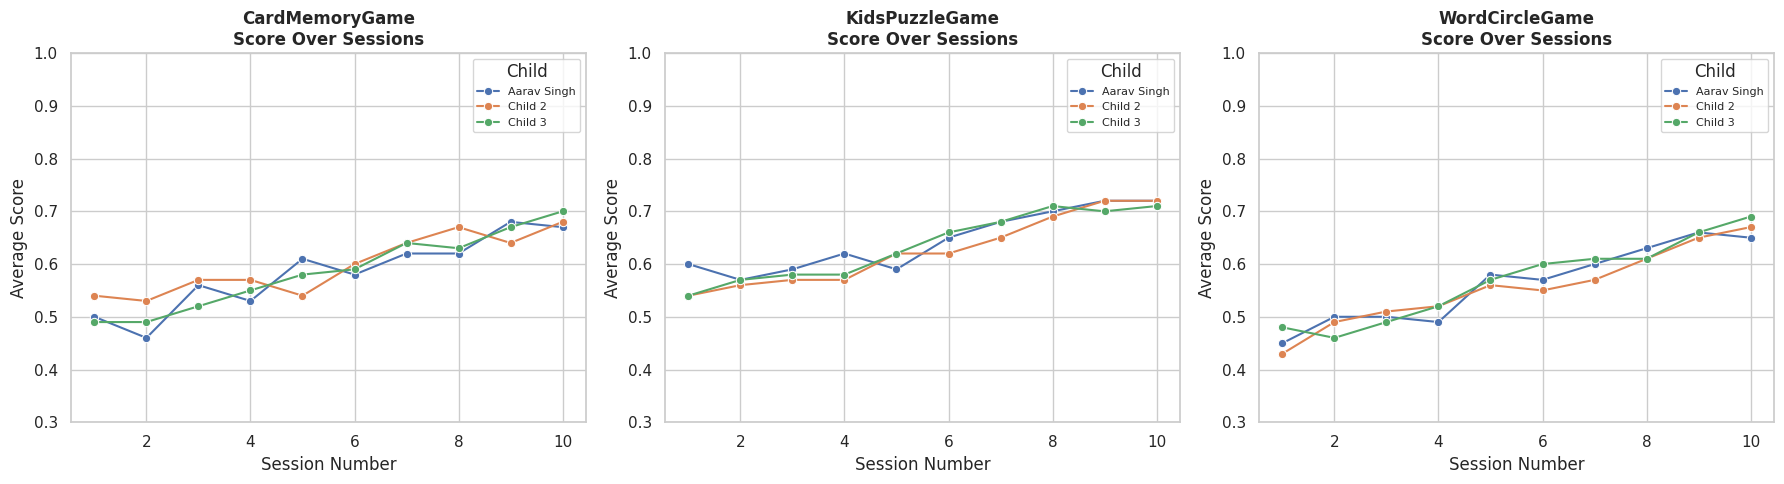

✅ Chart 1 saved

Generating Chart 2: Card Memory Moves per Theme...


/tmp/ipykernel_4483/2793369667.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x="theme_name", y="moves_taken",


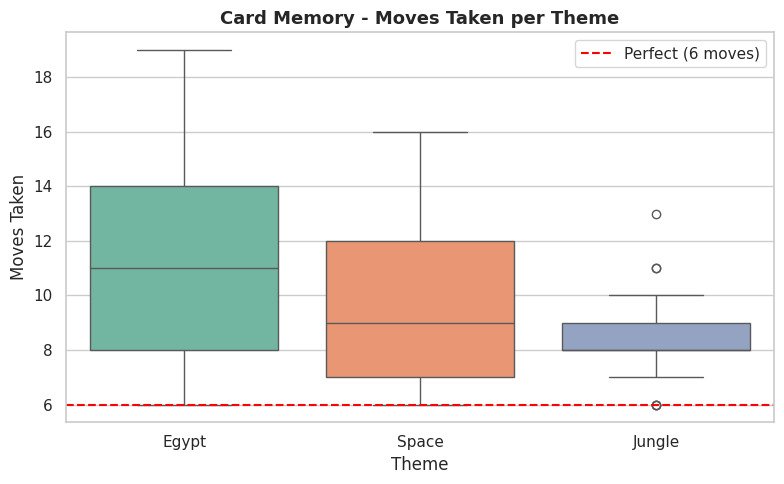

✅ Chart 2 saved

Generating Chart 3: Word Circle Completion Rate...


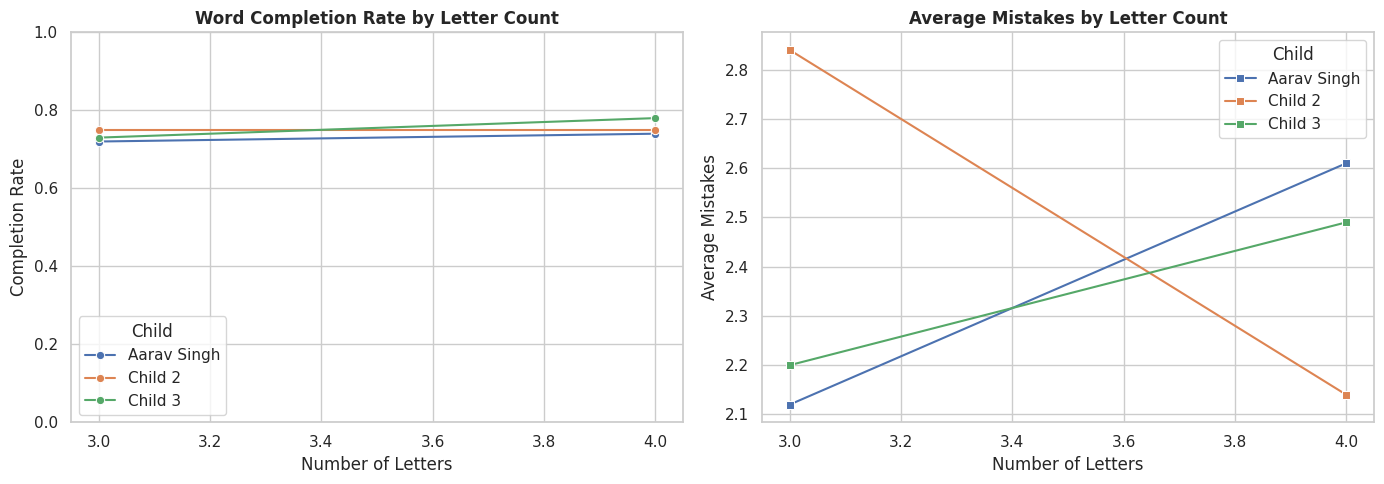

✅ Chart 3 saved

Generating Chart 4: Kids Puzzle Category Heatmap...


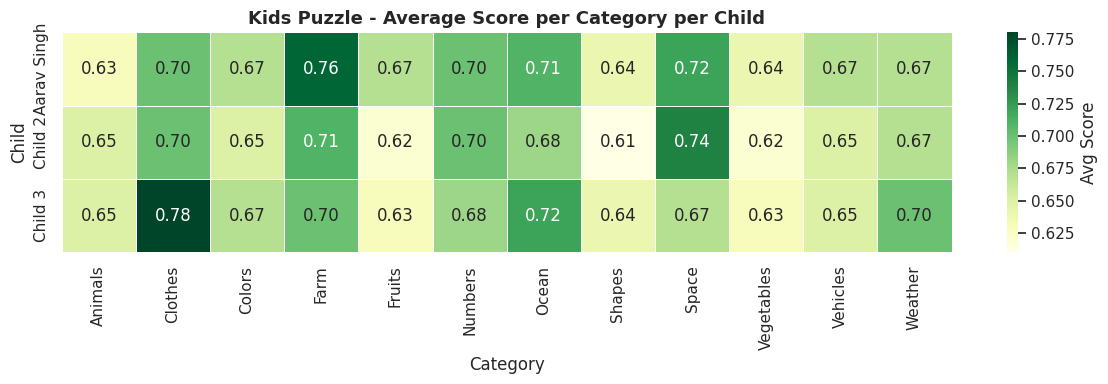

✅ Chart 4 saved

Generating Chart 5: Game Score vs EEG Attention...


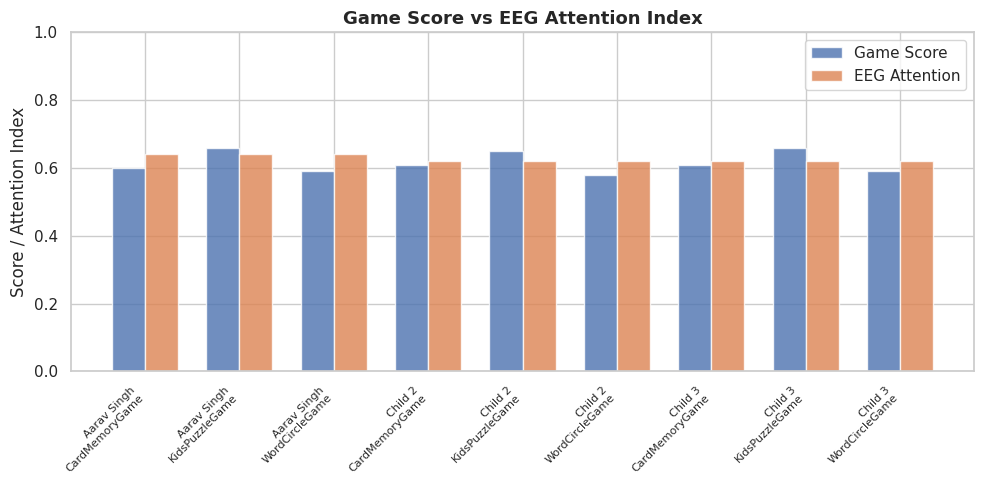

✅ Chart 5 saved

Generating Chart 6: Levels Completed vs Highest Level...


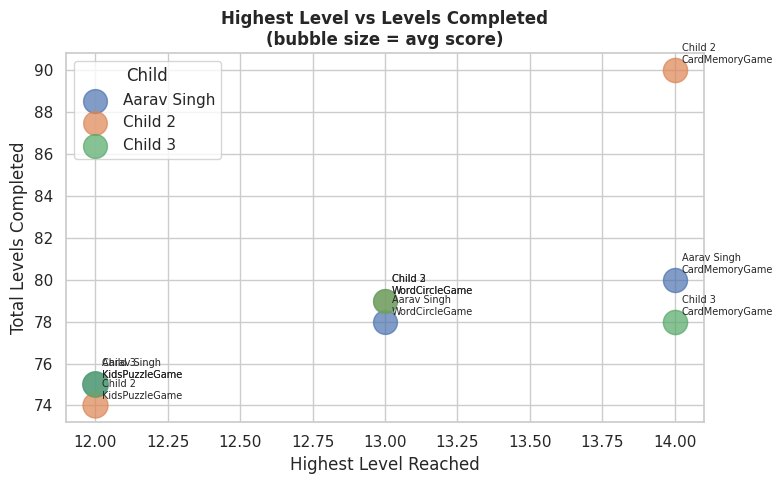

✅ Chart 6 saved

CELL 11 COMPLETE - ALL CHARTS GENERATED
  ✅ chart1_score_trends.png     - Line:    Score improvement over sessions
  ✅ chart2_card_moves.png       - Box:     Moves per theme (CardMemory)
  ✅ chart3_word_analysis.png    - Line:    Word completion & mistakes
  ✅ chart4_puzzle_heatmap.png   - Heatmap: Category scores (KidsPuzzle)
  ✅ chart5_game_vs_eeg.png      - Bar:     Game score vs EEG attention
  ✅ chart6_levels_scatter.png   - Scatter: Highest level vs completed

=== COMPLETE PROJECT DB SUMMARY ===
                   section  count
0          Basic DB Tables     14
1           Game DB Tables      6
2      Total Game Sessions     90
3      Total Level Results    765
4  Total Clinical Sessions     90
5         Total EEG Epochs    450


In [ ]:
# CELL 11: GAME VISUALIZATIONS

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

db_path = "/content/ccrp_demo.db"
con = sqlite3.connect(db_path)

def q(sql):
    return pd.read_sql_query(sql, con)

sns.set_theme(style="whitegrid")
COLORS = ["#4C72B0", "#DD8452", "#55A868"]

# ============================================================
# CHART 1: Score Improvement Trend Over Sessions (Line Chart)
# ============================================================
print("Generating Chart 1: Score Improvement Trend...")

df1 = q("""
SELECT u.full_name AS child_name,
       gc.game_name,
       gs.started_at,
       ROW_NUMBER() OVER (
           PARTITION BY gs.child_id, gs.game_id
           ORDER BY gs.started_at
       ) AS session_number,
       ROUND(AVG(glr.score),2) AS avg_score
FROM game_sessions gs
JOIN game_catalog gc ON gc.game_id = gs.game_id
JOIN game_level_results glr ON glr.game_session_id = gs.game_session_id
JOIN child_profiles c ON c.child_id = gs.child_id
JOIN users u ON u.user_id = c.user_id
GROUP BY gs.game_session_id
ORDER BY gs.child_id, gc.game_name, gs.started_at;
""")

games = df1['game_name'].unique()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, game in enumerate(games):
    game_df = df1[df1['game_name'] == game]
    sns.lineplot(
        data=game_df,
        x="session_number",
        y="avg_score",
        hue="child_name",
        marker="o",
        palette=COLORS,
        ax=axes[idx]
    )
    axes[idx].set_title(f"{game}\nScore Over Sessions",
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel("Session Number")
    axes[idx].set_ylabel("Average Score")
    axes[idx].set_ylim(0.3, 1.0)
    axes[idx].legend(title="Child", fontsize=8)

plt.tight_layout()
plt.savefig("/content/chart1_score_trends.png", dpi=150)
plt.show()
print("✅ Chart 1 saved")

# ============================================================
# CHART 2: Card Memory - Moves Taken per Theme (Box Plot)
# ============================================================
print("\nGenerating Chart 2: Card Memory Moves per Theme...")

df2 = q("""
SELECT u.full_name AS child_name,
       cmd.theme_name,
       cmd.moves_taken,
       glr.score
FROM card_memory_details cmd
JOIN game_level_results glr ON glr.level_result_id = cmd.level_result_id
JOIN game_sessions gs ON gs.game_session_id = glr.game_session_id
JOIN child_profiles c ON c.child_id = gs.child_id
JOIN users u ON u.user_id = c.user_id;
""")

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df2, x="theme_name", y="moves_taken",
            palette="Set2", ax=ax)
ax.set_title("Card Memory - Moves Taken per Theme",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Theme")
ax.set_ylabel("Moves Taken")
ax.axhline(y=6, color='red', linestyle='--',
           linewidth=1.5, label='Perfect (6 moves)')
ax.legend()

plt.tight_layout()
plt.savefig("/content/chart2_card_moves.png", dpi=150)
plt.show()
print("✅ Chart 2 saved")

# ============================================================
# CHART 3: Word Circle - Word Completion Rate by Letters
# ============================================================
print("\nGenerating Chart 3: Word Circle Completion Rate...")

df3 = q("""
SELECT u.full_name AS child_name,
       wcd.letters_count,
       ROUND(AVG(wcd.words_found * 1.0 / wcd.total_words),2) AS completion_rate,
       ROUND(AVG(wcd.hints_used),2) AS avg_hints,
       ROUND(AVG(wcd.mistakes_count),2) AS avg_mistakes
FROM word_circle_details wcd
JOIN game_level_results glr ON glr.level_result_id = wcd.level_result_id
JOIN game_sessions gs ON gs.game_session_id = glr.game_session_id
JOIN child_profiles c ON c.child_id = gs.child_id
JOIN users u ON u.user_id = c.user_id
GROUP BY u.full_name, wcd.letters_count;
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=df3, x="letters_count", y="completion_rate",
             hue="child_name", marker="o", palette=COLORS, ax=axes[0])
axes[0].set_title("Word Completion Rate by Letter Count",
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel("Number of Letters")
axes[0].set_ylabel("Completion Rate")
axes[0].set_ylim(0, 1)
axes[0].legend(title="Child")

sns.lineplot(data=df3, x="letters_count", y="avg_mistakes",
             hue="child_name", marker="s", palette=COLORS, ax=axes[1])
axes[1].set_title("Average Mistakes by Letter Count",
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel("Number of Letters")
axes[1].set_ylabel("Average Mistakes")
axes[1].legend(title="Child")

plt.tight_layout()
plt.savefig("/content/chart3_word_analysis.png", dpi=150)
plt.show()
print("✅ Chart 3 saved")

# ============================================================
# CHART 4: Kids Puzzle - Category Heatmap
# ============================================================
print("\nGenerating Chart 4: Kids Puzzle Category Heatmap...")

df4 = q("""
SELECT u.full_name AS child_name,
       kpd.category_name,
       ROUND(AVG(glr.score),2) AS avg_score
FROM kids_puzzle_details kpd
JOIN game_level_results glr ON glr.level_result_id = kpd.level_result_id
JOIN game_sessions gs ON gs.game_session_id = glr.game_session_id
JOIN child_profiles c ON c.child_id = gs.child_id
JOIN users u ON u.user_id = c.user_id
GROUP BY u.full_name, kpd.category_name
ORDER BY avg_score DESC;
""")

pivot4 = df4.pivot(index="child_name",
                   columns="category_name",
                   values="avg_score")

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(pivot4, annot=True, fmt=".2f",
            cmap="YlGn", linewidths=0.5,
            cbar_kws={'label': 'Avg Score'}, ax=ax)
ax.set_title("Kids Puzzle - Average Score per Category per Child",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Category")
ax.set_ylabel("Child")

plt.tight_layout()
plt.savefig("/content/chart4_puzzle_heatmap.png", dpi=150)
plt.show()
print("✅ Chart 4 saved")

# ============================================================
# CHART 5: Game Score vs EEG Attention Comparison
# ============================================================
print("\nGenerating Chart 5: Game Score vs EEG Attention...")

df5 = q("""
SELECT u.full_name AS child_name,
       gc.game_name,
       ROUND(AVG(glr.score),2) AS game_avg_score,
       ROUND(AVG(ep.attention_idx),2) AS eeg_avg_attention
FROM game_sessions gs
JOIN game_catalog gc ON gc.game_id = gs.game_id
JOIN game_level_results glr ON glr.game_session_id = gs.game_session_id
JOIN child_profiles c ON c.child_id = gs.child_id
JOIN users u ON u.user_id = c.user_id
LEFT JOIN sessions s ON s.child_id = gs.child_id
LEFT JOIN eeg_recordings er ON er.session_id = s.session_id
LEFT JOIN eeg_epochs ep ON ep.eeg_id = er.eeg_id
GROUP BY u.full_name, gc.game_name;
""")

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(df5))
width = 0.35

ax.bar([i - width/2 for i in x],
       df5['game_avg_score'],
       width, label='Game Score',
       color='#4C72B0', alpha=0.8)
ax.bar([i + width/2 for i in x],
       df5['eeg_avg_attention'],
       width, label='EEG Attention',
       color='#DD8452', alpha=0.8)

ax.set_title("Game Score vs EEG Attention Index",
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{r['child_name']}\n{r['game_name']}"
     for _, r in df5.iterrows()],
    rotation=45, ha='right', fontsize=8
)
ax.set_ylabel("Score / Attention Index")
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.savefig("/content/chart5_game_vs_eeg.png", dpi=150)
plt.show()
print("✅ Chart 5 saved")

# ============================================================
# CHART 6: Levels Completed vs Highest Level (Scatter)
# ============================================================
print("\nGenerating Chart 6: Levels Completed vs Highest Level...")

df6 = q("""
SELECT u.full_name AS child_name,
       gc.game_name,
       MAX(glr.level_number) AS highest_level,
       SUM(glr.completed) AS levels_completed,
       ROUND(AVG(glr.score),2) AS avg_score
FROM game_sessions gs
JOIN game_catalog gc ON gc.game_id = gs.game_id
JOIN game_level_results glr ON glr.game_session_id = gs.game_session_id
JOIN child_profiles c ON c.child_id = gs.child_id
JOIN users u ON u.user_id = c.user_id
GROUP BY u.full_name, gc.game_name;
""")

fig, ax = plt.subplots(figsize=(8, 5))

child_names = ['Aarav Singh', 'Child 2', 'Child 3']

for _, row in df6.iterrows():
    color_idx = child_names.index(row['child_name'])
    ax.scatter(
        row['highest_level'],
        row['levels_completed'],
        c=COLORS[color_idx],
        s=row['avg_score'] * 500,
        alpha=0.7,
        label=row['child_name']
    )
    ax.annotate(
        f"{row['child_name']}\n{row['game_name']}",
        (row['highest_level'], row['levels_completed']),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=7
    )

handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), title="Child")

ax.set_title("Highest Level vs Levels Completed\n(bubble size = avg score)",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Highest Level Reached")
ax.set_ylabel("Total Levels Completed")

plt.tight_layout()
plt.savefig("/content/chart6_levels_scatter.png", dpi=150)
plt.show()
print("✅ Chart 6 saved")

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "="*55)
print("CELL 11 COMPLETE - ALL CHARTS GENERATED")
print("="*55)
charts = [
    "chart1_score_trends.png     - Line:    Score improvement over sessions",
    "chart2_card_moves.png       - Box:     Moves per theme (CardMemory)",
    "chart3_word_analysis.png    - Line:    Word completion & mistakes",
    "chart4_puzzle_heatmap.png   - Heatmap: Category scores (KidsPuzzle)",
    "chart5_game_vs_eeg.png      - Bar:     Game score vs EEG attention",
    "chart6_levels_scatter.png   - Scatter: Highest level vs completed",
]
for c in charts:
    print(f"  ✅ {c}")

print("\n=== COMPLETE PROJECT DB SUMMARY ===")
print(pd.read_sql_query("""
SELECT
    'Basic DB Tables' AS section,
    COUNT(*) AS count
FROM sqlite_master
WHERE type='table'
AND name NOT IN (
    'game_catalog','game_sessions','game_level_results',
    'card_memory_details','word_circle_details',
    'kids_puzzle_details','sqlite_sequence'
)
UNION ALL
SELECT
    'Game DB Tables',
    COUNT(*)
FROM sqlite_master
WHERE type='table'
AND name IN (
    'game_catalog','game_sessions','game_level_results',
    'card_memory_details','word_circle_details',
    'kids_puzzle_details'
)
UNION ALL
SELECT 'Total Game Sessions', COUNT(*) FROM game_sessions
UNION ALL
SELECT 'Total Level Results', COUNT(*) FROM game_level_results
UNION ALL
SELECT 'Total Clinical Sessions', COUNT(*) FROM sessions
UNION ALL
SELECT 'Total EEG Epochs', COUNT(*) FROM eeg_epochs;
""", con))

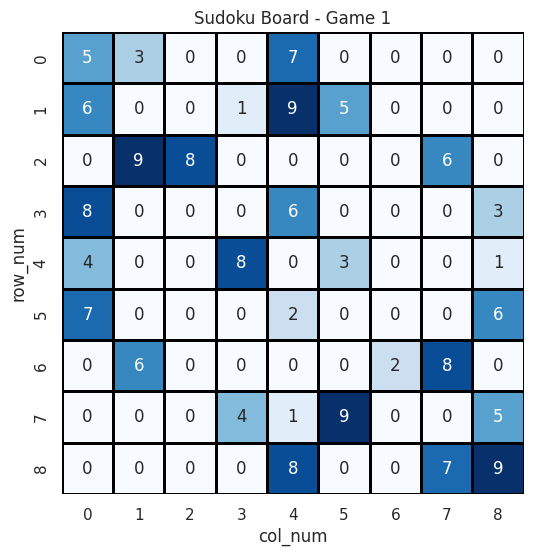

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sudoku_games = pd.DataFrame(columns=['game_id', 'player_name', 'difficulty', 'start_time', 'end_time'])

sudoku_board = pd.DataFrame(columns=['game_id', 'row_num', 'col_num', 'cell_value', 'is_initial'])

sudoku_games = pd.DataFrame([
    {'game_id': 1, 'player_name': 'Alice', 'difficulty': 'Easy', 'start_time': '2026-03-29 10:00:00', 'end_time': '2026-03-29 10:15:00'}
])

# Example Sudoku board (9x9)
# 0 = empty cell
sample_board = [
    [5,3,0,0,7,0,0,0,0],
    [6,0,0,1,9,5,0,0,0],
    [0,9,8,0,0,0,0,6,0],
    [8,0,0,0,6,0,0,0,3],
    [4,0,0,8,0,3,0,0,1],
    [7,0,0,0,2,0,0,0,6],
    [0,6,0,0,0,0,2,8,0],
    [0,0,0,4,1,9,0,0,5],
    [0,0,0,0,8,0,0,7,9]
]

# Insert into sudoku_board
board_rows = []
for r in range(9):
    for c in range(9):
        board_rows.append({
            'game_id': 1,
            'row_num': r,
            'col_num': c,
            'cell_value': sample_board[r][c],
            'is_initial': sample_board[r][c] != 0
        })

sudoku_board = pd.DataFrame(board_rows)

# Visualize Sudoku board safely
board_unique = sudoku_board.drop_duplicates(subset=['game_id','row_num','col_num'], keep='first')

first_game_board = board_unique[board_unique['game_id']==1].pivot(index='row_num', columns='col_num', values='cell_value')

plt.figure(figsize=(6,6))
sns.heatmap(first_game_board, annot=True, cbar=False, linewidths=1, linecolor='black', cmap='Blues', square=True)
plt.title('Sudoku Board - Game 1')
plt.show()